# Kidney CT Classification: Consolidated Research Notebook

**ResNet-50 vs. VGG-16 vs. MUL-CNN on CT-KIDNEY and RenSeg-KidneyCT**

This notebook consolidates and extends the two original per-dataset notebooks
(`research_task_4_output_task_Dataset_01.ipynb` for CT-KIDNEY and
`part_2_renseg_dataset.ipynb` for RenSeg-KidneyCT) into a single, reproducible,
publication-oriented pipeline.

**What is preserved from the original work**
- Three architectures compared on both datasets: ResNet-50 (fine-tuned,
  ImageNet-pretrained), VGG-16 (fine-tuned, ImageNet-pretrained), and MUL-CNN
  (a compact, from-scratch, five-stage custom CNN).
- Stratified 70/15/15 train/validation/test splits, 224x224 inputs,
  ImageNet normalisation, Adam optimiser, 10-epoch training budget.
- Dataset-specific checkpoint selection exactly as reported in the paper:
  **lowest validation loss** for CT-KIDNEY, **highest validation accuracy**
  for RenSeg-KidneyCT.
- Grad-CAM explainability for every trained model (Section 15).

**What this notebook adds**
1. A single configuration-driven pipeline shared by both datasets (no
   duplicated code between datasets).
2. A parameter-efficient MUL-CNN architecture (Section 8) using
   squeeze-and-excitation channel attention, one depthwise-separable
   convolution, and zero-parameter residual connections on top of the
   original five-stage design, keeping the parameter count modest relative
   to the ResNet-50 / VGG-16 baselines.
3. An augmentation ablation (with vs. without training-time augmentation)
   directly addressing the paper's stated but previously undelivered
   research objective on augmentation sensitivity (Section 16).
4. A multi-seed robustness check for MUL-CNN (the paper's central
   contribution) reporting mean +/- standard deviation across seeds
   (Section 14).
5. Post-hoc statistical testing -- McNemar's test between every model pair,
   and bootstrap confidence intervals for accuracy and F1 -- computed from
   existing test-set predictions at effectively no extra compute cost
   (Section 13).
6. A lightweight robustness/generalisation stress test: test-set accuracy
   under Gaussian noise, brightness shift, and blur, simulating
   acquisition/scanner variability (Section 14).
7. Publication-ready figure generation into a dedicated `figures/` directory
   (300 DPI, PNG + vector PDF where appropriate, consistent typography,
   yellow-gradient confusion matrices), including cross-dataset/cross-model
   comparative charts (Section 17).
8. An explicit, heavily-labelled dataset-statistics report and a final
   consolidated results summary with all tables exported to CSV/Markdown
   for direct reuse when rewriting the paper (Sections 4 and 18).

**How to run.** Run cells top-to-bottom. Section 2 is the single place to
edit dataset paths / hyperparameters / which optional experiments run.
Everything downstream reads from `GLOBAL_CFG` / `DATASETS_CFG` -- nothing
important is hard-coded further down. The primary experiments (Section 12)
must run before Sections 13-18, since those all reuse the trained models,
stored predictions, and histories produced there.


---
## 1. Environment and Imports

Installs and imports every dependency used anywhere in the notebook. Run this
cell first. GPU is strongly recommended (the original notebooks were run on
an NVIDIA RTX 4070, 8GB VRAM) -- CPU execution will work but will be
substantially slower, especially for ResNet-50/VGG-16 fine-tuning across two
datasets.


In [1]:
# ----------------------------------------------------------------------------
# 1.1 Install dependencies (uncomment if running in a fresh environment)
# ----------------------------------------------------------------------------
# !pip install torch torchvision torchaudio --upgrade --quiet
# !pip install torchsummary grad-cam opencv-python kagglehub --quiet
# !pip install matplotlib seaborn scikit-learn pandas numpy tqdm Pillow scipy --quiet

# ----------------------------------------------------------------------------
# 1.2 Imports
# ----------------------------------------------------------------------------
import os
import gc
import copy
import time
import json
import random
import warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import cv2
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
try:
    from torchsummary import summary as torch_summary
except ImportError:
    torch_summary = None

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, precision_score, recall_score, f1_score
)
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

print("Environment ready.")
print(f"  torch version        : {torch.__version__}")
print(f"  torchvision version  : {torchvision.__version__}")
print(f"  CUDA available       : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU                  : {torch.cuda.get_device_name(0)}")
    print(f"  GPU memory           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Environment ready.
  torch version        : 2.7.1+cu128
  torchvision version  : 0.22.1+cu128
  CUDA available       : True
  GPU                  : NVIDIA GeForce RTX 4070 Laptop GPU
  GPU memory           : 8.59 GB


---
## 2. Configuration and Reproducibility

All paths, hyperparameters, and settings used anywhere in the notebook are
centralised here. **Nothing important is hard-coded in later cells** --
downstream code reads from `GLOBAL_CFG` / `DATASETS_CFG`. Edit this cell to
change dataset paths, hyperparameters, or which additional experiments run.

Two dataset paths are used:
- **CT-KIDNEY** is downloaded automatically via `kagglehub`.
- **RenSeg-KidneyCT** must be downloaded manually from Mendeley Data
  (doi: 10.17632/rxfk6t8f6x.1) and its local path set below.


In [2]:
# ----------------------------------------------------------------------------
# 2.1 Global reproducibility settings
# ----------------------------------------------------------------------------
SEED = 42

def set_seed(seed: int = SEED):
    """Set every relevant random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ----------------------------------------------------------------------------
# 2.2 Global experiment configuration
# ----------------------------------------------------------------------------
GLOBAL_CFG = {
    # --- core training hyperparameters (unchanged from the original notebooks) ---
    'image_size'        : 224,
    'batch_size'         : 16,
    'num_epochs'          : 10,
    'learning_rate'        : 1e-4,
    'weight_decay'          : 1e-4,
    'lr_scheduler_step'      : 5,
    'lr_scheduler_gamma'      : 0.1,
    'imagenet_mean'            : [0.485, 0.456, 0.406],
    'imagenet_std'               : [0.229, 0.224, 0.225],
    'train_val_test_split'         : (0.70, 0.15, 0.15),

    # --- augmentation parameters (unchanged from the original notebooks) ---
    'aug_rotation_degrees'           : 15,
    'aug_hflip_p'                      : 0.5,
    'aug_vflip_p'                        : 0.5,
    'aug_affine_scale'                     : (0.9, 1.1),
    'aug_color_jitter_brightness'             : 0.2,
    'aug_color_jitter_contrast'                 : 0.2,

    # --- dataloader ---
    'num_workers'  : 0 if os.name == 'nt' else 2,
    'pin_memory'     : torch.cuda.is_available(),

    # --- which models make up the PRIMARY comparison reported in the paper ---
    'primary_models' : ['ResNet-50', 'VGG-16', 'MUL-CNN'],

    # --- additional-experiment toggles (all cheap; see Section 14/16 markdown
    #     for the rationale behind each) ---
    'run_augmentation_ablation' : True,   # MUL-CNN with vs without augmentation
    'run_seed_robustness'       : True,   # MUL-CNN retrained across extra seeds
    'seed_robustness_extra_seeds': [7, 123],   # SEED (42) + these = 3 total runs
    'run_perturbation_robustness': True,  # test-set robustness under noise/blur/brightness
    'run_gradcam'                : True,  # Grad-CAM explainability (Section 15)
    'gradcam_num_samples_per_class': 1,   # one correctly-classified example per class, per model

    # --- output locations ---
    'figures_dir'   : 'figures',
    'checkpoints_dir': 'checkpoints',
    'results_dir'    : 'results',
}

for d in [GLOBAL_CFG['figures_dir'], GLOBAL_CFG['checkpoints_dir'], GLOBAL_CFG['results_dir']]:
    Path(d).mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------------------
# 2.3 Per-dataset configuration
# ----------------------------------------------------------------------------
DATASETS_CFG = {
    'CT-KIDNEY': {
        'display_name'      : 'CT-KIDNEY',
        'citation'            : 'Islam et al. (2021), Kaggle: nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone',
        'source'                : 'kagglehub',
        'kaggle_id'               : 'nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone',
        'class_names'               : ['Normal', 'Cyst', 'Tumor', 'Stone'],
        'loader_type'                 : 'walk_substring',
        # dataset-specific checkpoint metric, EXACTLY as reported in the paper:
        # CT-KIDNEY selects the checkpoint with the LOWEST validation loss.
        'checkpoint_metric'             : 'val_loss',
        'figures_subdir'                  : 'CT-KIDNEY',
    },
    'RenSeg-KidneyCT': {
        'display_name'      : 'RenSeg-KidneyCT',
        'citation'            : 'Faruk & Alam (2025), Mendeley Data V1, doi: 10.17632/rxfk6t8f6x.1',
        'source'                : 'local',
        # EDIT THIS PATH to point at your local RenSeg-KidneyCT download:
        'local_path'               : r"C:\Users\Zeshan\Desktop\uni-research-task\RenSeg-KidneyCT",
        'class_names'                 : ['Normal', 'Stone', 'Tumor'],
        'loader_type'                   : 'folder_map',
        'folder_map'                       : {
            'Normal Kidney (Unannotated)'        : 0,
            'Renal Calculi (Annotated)(stone)'      : 1,
            'Renal Carcinoma (Annotated)(tumor)'      : 2,
        },
        # RenSeg-KidneyCT selects the checkpoint with the HIGHEST validation
        # accuracy, exactly as reported in the paper.
        'checkpoint_metric'                          : 'val_acc',
        'figures_subdir'                                : 'RenSeg-KidneyCT',
    },
}

for _dkey, _dcfg in DATASETS_CFG.items():
    _dcfg['num_classes'] = len(_dcfg['class_names'])
    (Path(GLOBAL_CFG['figures_dir']) / _dcfg['figures_subdir']).mkdir(parents=True, exist_ok=True)

print("Configuration loaded.")
print(f"Device: {DEVICE}")
print(f"Datasets configured: {list(DATASETS_CFG.keys())}")
for _dkey, _dcfg in DATASETS_CFG.items():
    print(f"  - {_dkey}: {_dcfg['num_classes']} classes {_dcfg['class_names']}, "
          f"checkpoint metric = {_dcfg['checkpoint_metric']}, source = {_dcfg['source']}")


Configuration loaded.
Device: cuda
Datasets configured: ['CT-KIDNEY', 'RenSeg-KidneyCT']
  - CT-KIDNEY: 4 classes ['Normal', 'Cyst', 'Tumor', 'Stone'], checkpoint metric = val_loss, source = kagglehub
  - RenSeg-KidneyCT: 3 classes ['Normal', 'Stone', 'Tumor'], checkpoint metric = val_acc, source = local


### 2.4 Publication figure style

A single, consistent style is applied to every figure generated by this
notebook (professional typography, adequate font sizes, high-resolution
output) so that all exported figures already match the visual conventions
expected in a Springer Nature / MDPI manuscript, with no manual re-styling
needed before submission. A dedicated **yellow-gradient colormap** (light
yellow to dark amber/brown, per the requested style) is defined here and
reused for every confusion matrix in the notebook -- replacing the default
blue colormap used in the original notebooks.


In [3]:
# ----------------------------------------------------------------------------
# 2.4 Global matplotlib style + yellow confusion-matrix colormap
# ----------------------------------------------------------------------------
mpl.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.titleweight': 'bold',
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'savefig.bbox': 'tight',
})

# Light-yellow -> gold -> dark amber/brown, chosen for sufficient contrast so
# that annotation text stays legible across the full range of cell counts.
YELLOW_CMAP = LinearSegmentedColormap.from_list(
    'kidney_yellow',
    ['#FFFDE7', '#FFF59D', '#FDD835', '#F9A825', '#E65100'],
    N=256,
)

def save_fig(fig, dataset_key: str, filename: str, also_pdf: bool = True):
    """Save a figure into figures/<dataset>/ at publication resolution.
    Saves both PNG (300 DPI, universally embeddable) and, for vector-friendly
    content (bar charts, confusion matrices), a PDF for print-quality inclusion.
    dataset_key may be 'comparative' for cross-dataset figures."""
    subdir = DATASETS_CFG[dataset_key]['figures_subdir'] if dataset_key in DATASETS_CFG else dataset_key
    out_dir = Path(GLOBAL_CFG['figures_dir']) / subdir
    out_dir.mkdir(parents=True, exist_ok=True)
    png_path = out_dir / f'{filename}.png'
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    if also_pdf:
        pdf_path = out_dir / f'{filename}.pdf'
        fig.savefig(pdf_path, bbox_inches='tight')
    return png_path

(Path(GLOBAL_CFG['figures_dir']) / 'comparative').mkdir(parents=True, exist_ok=True)
print("Publication figure style applied. Yellow colormap 'YELLOW_CMAP' ready.")


Publication figure style applied. Yellow colormap 'YELLOW_CMAP' ready.


---
## 3. Dataset Loading

A single `KidneyDataset` class and a single `load_dataset()` dispatcher serve
**both** datasets. `load_dataset()` reads `DATASETS_CFG[dataset_key]` and
dispatches to the appropriate loading strategy (`kagglehub` download +
substring-based folder walk for CT-KIDNEY; local path + explicit folder map
for RenSeg-KidneyCT) -- consolidating what were two separate, hand-written
loaders in the original notebooks into one reusable implementation.


In [4]:
# ----------------------------------------------------------------------------
# 3.1 Dataset class (shared by both datasets)
# ----------------------------------------------------------------------------
class KidneyDataset(Dataset):
    """Custom Dataset for CT-scan kidney images. Identical logic is reused for
    both CT-KIDNEY and RenSeg-KidneyCT; only the (path, label) lists differ."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Failed to load image: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label


# ----------------------------------------------------------------------------
# 3.2 Loading strategies
# ----------------------------------------------------------------------------
def _load_via_kagglehub(cfg):
    """Download the dataset via kagglehub and walk the directory tree,
    assigning labels by substring match on folder/file name (CT-KIDNEY)."""
    import kagglehub
    data_path = kagglehub.dataset_download(cfg['kaggle_id'])
    print(f"  kagglehub download path: {data_path}")

    class_names = cfg['class_names']
    name_to_idx = {name.lower(): idx for idx, name in enumerate(class_names)}

    image_paths, labels = [], []
    for root, _dirs, files in os.walk(data_path):
        folder_name = os.path.basename(root).lower()
        for file in files:
            if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            matched_idx = None
            for cname_lower, idx in name_to_idx.items():
                if cname_lower in folder_name or cname_lower in file.lower():
                    matched_idx = idx
                    break
            if matched_idx is None:
                continue
            image_paths.append(os.path.join(root, file))
            labels.append(matched_idx)
    return image_paths, labels


def _load_via_folder_map(cfg):
    """Load from an explicit {folder_name: class_index} map at a local path
    (RenSeg-KidneyCT)."""
    data_path = cfg['local_path']
    folder_map = cfg['folder_map']
    class_names = cfg['class_names']

    image_paths, labels = [], []
    for folder_name, class_idx in folder_map.items():
        folder_path = os.path.join(data_path, folder_name)
        if not os.path.exists(folder_path):
            print(f"  WARNING: folder not found: {folder_path}")
            continue
        files = [f for f in os.listdir(folder_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))]
        print(f"  {folder_name} -> {class_names[class_idx]}: {len(files)} images")
        for file in files:
            image_paths.append(os.path.join(folder_path, file))
            labels.append(class_idx)
    return image_paths, labels


_LOADERS = {
    'walk_substring': _load_via_kagglehub,
    'folder_map': _load_via_folder_map,
}


def load_dataset(dataset_key: str) -> Tuple[List[str], List[int]]:
    """Unified dataset loader: dispatches on DATASETS_CFG[dataset_key]['loader_type']."""
    cfg = DATASETS_CFG[dataset_key]
    print(f"\nLoading {dataset_key} (source: {cfg['source']}) ...")
    loader_fn = _LOADERS[cfg['loader_type']]
    image_paths, labels = loader_fn(cfg)
    if len(image_paths) == 0:
        raise RuntimeError(
            f"No images were loaded for {dataset_key}. Check the configured "
            f"path/loader in DATASETS_CFG['{dataset_key}']."
        )
    print(f"  Total images loaded: {len(image_paths)}")
    return image_paths, labels


# ----------------------------------------------------------------------------
# 3.3 Load both datasets now (raw paths + labels only; splitting happens in Section 6)
# ----------------------------------------------------------------------------
RAW_DATA = {}
for _dkey in DATASETS_CFG:
    _paths, _labels = load_dataset(_dkey)
    RAW_DATA[_dkey] = {'image_paths': _paths, 'labels': _labels}

print("\nAll datasets loaded:")
for _dkey, _d in RAW_DATA.items():
    print(f"  {_dkey}: {len(_d['image_paths'])} images")



Loading CT-KIDNEY (source: kagglehub) ...
Resuming download from 1572864000 bytes (55055308 bytes left)...
Resuming download to C:\Users\Zeshan\.cache\kagglehub\datasets\nazmul0087\ct-kidney-dataset-normal-cyst-tumor-and-stone\1.archive (1572864000/1627919308) bytes left.


100%|██████████| 1.52G/1.52G [00:37<00:00, 1.46MB/s]

Extracting files...


  kagglehub download path: C:\Users\Zeshan\.cache\kagglehub\datasets\nazmul0087\ct-kidney-dataset-normal-cyst-tumor-and-stone\versions\1
  Total images loaded: 12446

Loading RenSeg-KidneyCT (source: local) ...
  Normal Kidney (Unannotated) -> Normal: 5077 images
  Renal Calculi (Annotated)(stone) -> Stone: 1377 images
  Renal Carcinoma (Annotated)(tumor) -> Tumor: 2283 images
  Total images loaded: 8737

All datasets loaded:
  CT-KIDNEY: 12446 images
  RenSeg-KidneyCT: 8737 images


---
## 4. Dataset Statistics

Explicit, clearly-labelled dataset statistics for both datasets: total image
counts, per-class counts and percentages. (Split-level statistics -- train /
validation / test counts and per-split class distributions -- are reported in
Section 6, immediately after splitting, since they don't exist until the
split is performed.) These tables are the first thing to look at when using
this notebook's output to rewrite the paper's dataset-description section.


In [5]:
def report_dataset_statistics(dataset_key: str) -> pd.DataFrame:
    """Print and return a clearly-formatted per-class statistics table for one dataset."""
    cfg = DATASETS_CFG[dataset_key]
    labels = RAW_DATA[dataset_key]['labels']
    class_names = cfg['class_names']
    total = len(labels)

    rows = []
    for idx, cname in enumerate(class_names):
        count = labels.count(idx)
        rows.append({'Class': cname, 'Count': count, 'Percentage': f"{count/total*100:.2f}%"})
    df = pd.DataFrame(rows)

    print("=" * 78)
    print(f"DATASET STATISTICS: {dataset_key}  ({cfg['citation']})")
    print("=" * 78)
    print(f"Total images     : {total}")
    print(f"Number of classes: {len(class_names)}")
    print(f"Class names      : {class_names}")
    print()
    display(df)
    print("=" * 78)
    return df


DATASET_STATS = {}
for _dkey in DATASETS_CFG:
    DATASET_STATS[_dkey] = report_dataset_statistics(_dkey)


DATASET STATISTICS: CT-KIDNEY  (Islam et al. (2021), Kaggle: nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone)
Total images     : 12446
Number of classes: 4
Class names      : ['Normal', 'Cyst', 'Tumor', 'Stone']



,Class,Count,Percentage
0,Normal,5077,40.79%
1,Cyst,3709,29.80%
2,Tumor,2283,18.34%
3,Stone,1377,11.06%


DATASET STATISTICS: RenSeg-KidneyCT  (Faruk & Alam (2025), Mendeley Data V1, doi: 10.17632/rxfk6t8f6x.1)
Total images     : 8737
Number of classes: 3
Class names      : ['Normal', 'Stone', 'Tumor']



,Class,Count,Percentage
0,Normal,5077,58.11%
1,Stone,1377,15.76%
2,Tumor,2283,26.13%


---
## 5. Data Preprocessing

Preprocessing transforms are shared across both datasets and both
train/val/test splits differ only in whether augmentation is applied.
Every image is resized to 224x224 and normalised with ImageNet channel
statistics (required for the ImageNet-pretrained ResNet-50/VGG-16 backbones,
and applied identically to MUL-CNN for a fair comparison). All parameters
come from `GLOBAL_CFG` (Section 2) -- nothing is re-hard-coded here.


In [6]:
IMG_SIZE = GLOBAL_CFG['image_size']
MEAN = GLOBAL_CFG['imagenet_mean']
STD = GLOBAL_CFG['imagenet_std']

def build_transforms(augment: bool):
    """Build a torchvision transform pipeline. augment=True adds the training-time
    augmentation stack (Section 7); augment=False is used for validation/test, and
    also for the 'no augmentation' ablation condition in Section 16."""
    if augment:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomRotation(GLOBAL_CFG['aug_rotation_degrees']),
            transforms.RandomHorizontalFlip(p=GLOBAL_CFG['aug_hflip_p']),
            transforms.RandomVerticalFlip(p=GLOBAL_CFG['aug_vflip_p']),
            transforms.RandomAffine(degrees=0, scale=GLOBAL_CFG['aug_affine_scale']),
            transforms.ColorJitter(brightness=GLOBAL_CFG['aug_color_jitter_brightness'],
                                    contrast=GLOBAL_CFG['aug_color_jitter_contrast']),
            transforms.ToTensor(),
            transforms.Normalize(mean=MEAN, std=STD),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=MEAN, std=STD),
        ])

TRAIN_TRANSFORM = build_transforms(augment=True)
EVAL_TRANSFORM = build_transforms(augment=False)   # used for val, test, and no-aug ablation

def denormalize(tensor, mean=MEAN, std=STD):
    """Undo ImageNet normalisation for visualisation."""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Normalisation - mean: {MEAN}, std: {STD}")
print("Train transform steps:", [type(t).__name__ for t in TRAIN_TRANSFORM.transforms])
print("Eval  transform steps:", [type(t).__name__ for t in EVAL_TRANSFORM.transforms])


Image size: 224x224
Normalisation - mean: [0.485, 0.456, 0.406], std: [0.229, 0.224, 0.225]
Train transform steps: ['Resize', 'RandomRotation', 'RandomHorizontalFlip', 'RandomVerticalFlip', 'RandomAffine', 'ColorJitter', 'ToTensor', 'Normalize']
Eval  transform steps: ['Resize', 'ToTensor', 'Normalize']


---
## 6. Dataset Splitting

Stratified 70/15/15 train/validation/test splitting, identical protocol for
both datasets, seeded for reproducibility. Stratification preserves class
proportions in every split and guarantees no image appears in more than one
split (no data leakage). Explicit split-level statistics -- required by the
task -- are printed immediately after splitting: sizes and per-class
distribution for every split of every dataset.


In [7]:
def stratified_split(dataset_key: str, seed: int = SEED):
    """70/15/15 stratified split, identical protocol for both datasets."""
    cfg = DATASETS_CFG[dataset_key]
    image_paths = RAW_DATA[dataset_key]['image_paths']
    labels = RAW_DATA[dataset_key]['labels']
    train_frac, val_frac, test_frac = GLOBAL_CFG['train_val_test_split']

    train_paths, temp_paths, train_labels, temp_labels = train_test_split(
        image_paths, labels, test_size=(val_frac + test_frac),
        stratify=labels, random_state=seed
    )
    relative_test_frac = test_frac / (val_frac + test_frac)
    val_paths, test_paths, val_labels, test_labels = train_test_split(
        temp_paths, temp_labels, test_size=relative_test_frac,
        stratify=temp_labels, random_state=seed
    )
    return {
        'train': (train_paths, train_labels),
        'val': (val_paths, val_labels),
        'test': (test_paths, test_labels),
    }


def report_split_statistics(dataset_key: str, split: dict) -> pd.DataFrame:
    """Print and return a clearly-formatted per-split, per-class statistics table."""
    cfg = DATASETS_CFG[dataset_key]
    class_names = cfg['class_names']
    total = sum(len(split[s][0]) for s in ('train', 'val', 'test'))

    rows = []
    for split_name in ('train', 'val', 'test'):
        _, split_labels = split[split_name]
        row = {'Split': split_name.capitalize(), 'Total': len(split_labels)}
        for idx, cname in enumerate(class_names):
            row[cname] = split_labels.count(idx)
        rows.append(row)
    df = pd.DataFrame(rows)

    print("=" * 78)
    print(f"SPLIT STATISTICS: {dataset_key}")
    print("=" * 78)
    print(f"Total images: {total}  (train {GLOBAL_CFG['train_val_test_split'][0]*100:.0f}% / "
          f"val {GLOBAL_CFG['train_val_test_split'][1]*100:.0f}% / "
          f"test {GLOBAL_CFG['train_val_test_split'][2]*100:.0f}%, stratified, seed={SEED})")
    display(df)
    print("=" * 78)
    return df


SPLITS = {}
SPLIT_STATS = {}
for _dkey in DATASETS_CFG:
    SPLITS[_dkey] = stratified_split(_dkey, seed=SEED)
    SPLIT_STATS[_dkey] = report_split_statistics(_dkey, SPLITS[_dkey])


SPLIT STATISTICS: CT-KIDNEY
Total images: 12446  (train 70% / val 15% / test 15%, stratified, seed=42)


,Split,Total,Normal,Cyst,Tumor,Stone
0,Train,8712,3554,2596,1598,964
1,Val,1867,761,557,342,207
2,Test,1867,762,556,343,206


SPLIT STATISTICS: RenSeg-KidneyCT
Total images: 8737  (train 70% / val 15% / test 15%, stratified, seed=42)


,Split,Total,Normal,Stone,Tumor
0,Train,6115,3553,964,1598
1,Val,1311,762,206,343
2,Test,1311,762,207,342


---
## 7. Data Augmentation

Builds the PyTorch `Dataset`/`DataLoader` objects for every split of every
dataset (training data uses `TRAIN_TRANSFORM` from Section 5; validation and
test use `EVAL_TRANSFORM`), and visualises a batch of augmented training
images per dataset as a sanity check before any training begins.


In [8]:
LOADERS = {}
DATASETS_TORCH = {}

for _dkey in DATASETS_CFG:
    split = SPLITS[_dkey]
    train_ds = KidneyDataset(*split['train'], transform=TRAIN_TRANSFORM)
    val_ds = KidneyDataset(*split['val'], transform=EVAL_TRANSFORM)
    test_ds = KidneyDataset(*split['test'], transform=EVAL_TRANSFORM)

    DATASETS_TORCH[_dkey] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
    LOADERS[_dkey] = {
        'train': DataLoader(train_ds, batch_size=GLOBAL_CFG['batch_size'], shuffle=True,
                             num_workers=GLOBAL_CFG['num_workers'], pin_memory=GLOBAL_CFG['pin_memory']),
        'val': DataLoader(val_ds, batch_size=GLOBAL_CFG['batch_size'], shuffle=False,
                           num_workers=GLOBAL_CFG['num_workers'], pin_memory=GLOBAL_CFG['pin_memory']),
        'test': DataLoader(test_ds, batch_size=GLOBAL_CFG['batch_size'], shuffle=False,
                            num_workers=GLOBAL_CFG['num_workers'], pin_memory=GLOBAL_CFG['pin_memory']),
    }
    print(f"{_dkey}: train batches={len(LOADERS[_dkey]['train'])}, "
          f"val batches={len(LOADERS[_dkey]['val'])}, test batches={len(LOADERS[_dkey]['test'])} "
          f"(batch size={GLOBAL_CFG['batch_size']})")


CT-KIDNEY: train batches=545, val batches=117, test batches=117 (batch size=16)
RenSeg-KidneyCT: train batches=383, val batches=82, test batches=82 (batch size=16)


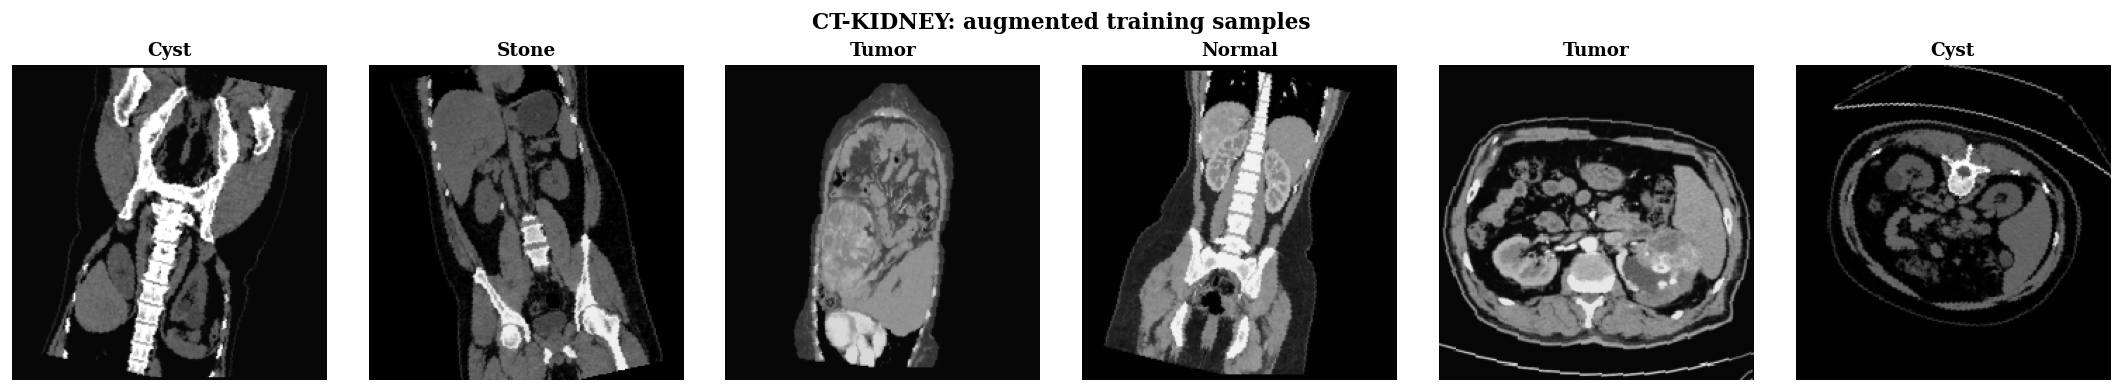

Saved: figures\CT-KIDNEY\augmented_samples.png


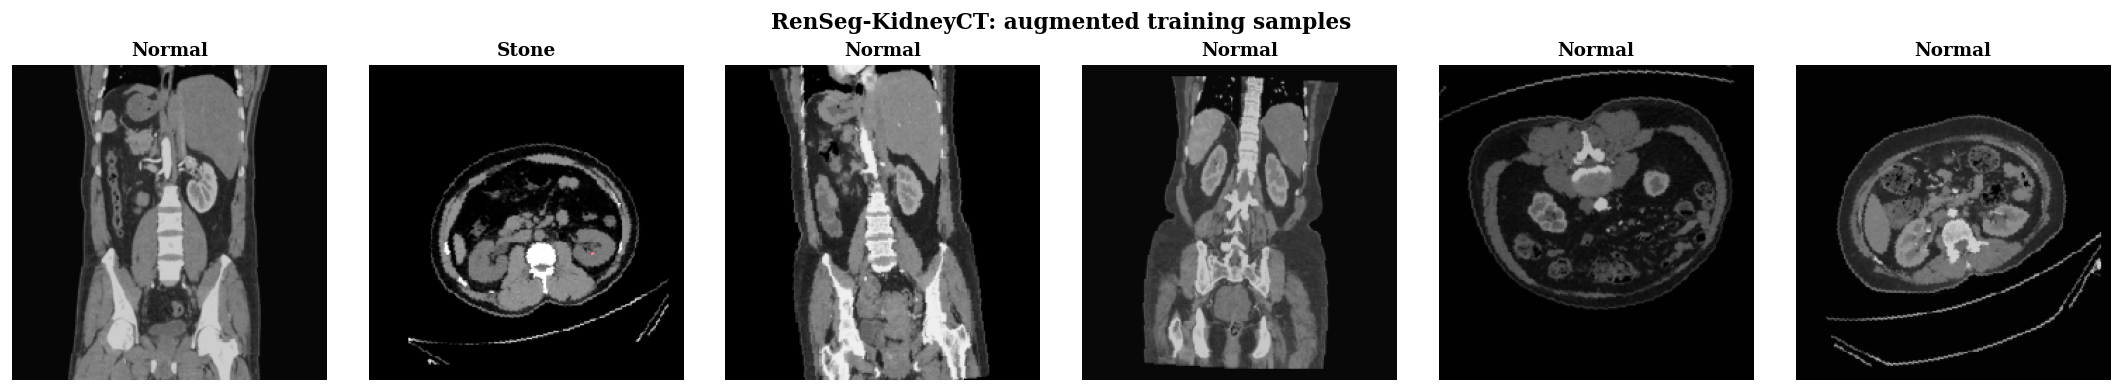

Saved: figures\RenSeg-KidneyCT\augmented_samples.png


In [9]:
def show_augmented_samples(dataset_key: str, n_samples: int = 6):
    """Visualise a few augmented training images and save to the figures directory."""
    cfg = DATASETS_CFG[dataset_key]
    class_names = cfg['class_names']
    train_ds = DATASETS_TORCH[dataset_key]['train']

    ncols = min(n_samples, 6)
    fig, axes = plt.subplots(1, ncols, figsize=(3 * ncols, 3.3))
    if ncols == 1:
        axes = [axes]
    rng = np.random.RandomState(SEED)
    for i in range(ncols):
        idx = rng.randint(0, len(train_ds))
        img, label = train_ds[idx]
        img = denormalize(img).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(class_names[label], fontsize=11)
        axes[i].axis('off')
    fig.suptitle(f'{dataset_key}: augmented training samples', fontsize=13, fontweight='bold')
    fig.tight_layout()
    save_path = save_fig(fig, dataset_key, 'augmented_samples', also_pdf=False)
    plt.show()
    print(f"Saved: {save_path}")

for _dkey in DATASETS_CFG:
    show_augmented_samples(_dkey)


---
## 8. Model Definitions

Three model constructors are defined:

1. **ResNet-50** and **VGG-16** -- ImageNet-pretrained, fine-tuned, with the
   same classifier heads as the original notebooks (unchanged, since these
   are standard baselines, not the paper's core lightweight-architecture
   contribution).
2. **MUL-CNN** -- a compact, from-scratch, five-stage custom CNN, kept
   consistent with the receptive-field progression used in the original
   notebooks and extended with three literature-grounded, parameter-
   efficient building blocks commonly used in medical-imaging CNNs:
   - **Squeeze-and-Excitation (SE) channel attention** (Hu et al., 2018)
     after every stage, letting the network recalibrate which feature
     channels matter most -- widely used in medical image classification to
     emphasise diagnostically relevant channels.
   - **One depthwise-separable convolution** (MobileNet-style; Howard et al.,
     2017) in the network's most parameter-heavy layer (the second
     512-channel convolution in stage 5), factorising a standard 3x3
     convolution into a per-channel spatial convolution plus a 1x1 channel
     mix, at a fraction of the parameter cost.
   - **Zero-parameter identity residual connections** inside stages 3-5
     (wherever input/output channel counts already match), improving
     gradient flow for a network trained entirely from random
     initialisation within a short, 10-epoch budget.

   These building blocks keep MUL-CNN's parameter count well below both
   ResNet-50 and VGG-16, which is the efficiency angle the paper relies on
   in place of an accuracy-only comparison.


In [10]:
# ----------------------------------------------------------------------------
# 8.1 ResNet-50 (unchanged from the original notebooks)
# ----------------------------------------------------------------------------
def create_resnet50(num_classes: int, pretrained: bool = True) -> nn.Module:
    model = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
    for param in list(model.parameters())[:-20]:
        param.requires_grad = False
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes),
    )
    return model


# ----------------------------------------------------------------------------
# 8.2 VGG-16 (unchanged from the original notebooks)
# ----------------------------------------------------------------------------
def create_vgg16(num_classes: int, pretrained: bool = True) -> nn.Module:
    model = models.vgg16(weights='IMAGENET1K_V1' if pretrained else None)
    for param in model.features[:-10].parameters():
        param.requires_grad = False
    model.classifier = nn.Sequential(
        nn.Linear(512 * 7 * 7, 4096),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(4096, 1024),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(1024, num_classes),
    )
    return model


In [11]:
# ----------------------------------------------------------------------------
# 8.3 MUL-CNN -- the compact, from-scratch custom CNN
# ----------------------------------------------------------------------------
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention (Hu et al., CVPR 2018)."""

    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        reduced = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w


class DepthwiseSeparableConv(nn.Module):
    """MobileNet-style depthwise-separable convolution: a per-channel spatial
    convolution followed by a 1x1 pointwise channel mix. For a 512->512, 3x3
    convolution this cuts parameters from ~2.36M to ~0.27M."""

    def __init__(self, in_ch: int, out_ch: int, kernel_size: int = 3, padding: int = 1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_ch, in_ch, kernel_size, padding=padding,
                                    groups=in_ch, bias=False)
        self.pointwise = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return self.act(x)


class MUL_CNN(nn.Module):
    """MUL-CNN: a compact five-stage custom CNN with SE channel attention on
    every stage, one depthwise-separable convolution in stage 5, and zero-
    parameter identity residual connections in stages 3-5. See the Section 8
    markdown for the full rationale.
    """

    def __init__(self, num_classes: int, se_reduction: int = 16):
        super().__init__()
        # Stage 1: 3 -> 32 (kept as standard convs: cheap, preserves fine low-level detail)
        self.conv1a = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.conv1b = nn.Sequential(nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.se1 = SEBlock(32, se_reduction)
        self.pool1 = nn.MaxPool2d(2, 2)

        # Stage 2: 32 -> 64 (standard convs)
        self.conv2a = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.conv2b = nn.Sequential(nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.se2 = SEBlock(64, se_reduction)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Stage 3: 64 -> 128 -> 128 -> 128, identity residual on the 3rd conv
        self.conv3a = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.conv3b = nn.Sequential(nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.conv3c = nn.Sequential(nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128))
        self.act3c = nn.ReLU(inplace=True)
        self.se3 = SEBlock(128, se_reduction)
        self.pool3 = nn.MaxPool2d(2, 2)

        # Stage 4: 128 -> 256 -> 256, identity residual on the 2nd conv
        self.conv4a = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.conv4b = nn.Sequential(nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256))
        self.act4b = nn.ReLU(inplace=True)
        self.se4 = SEBlock(256, se_reduction)
        self.pool4 = nn.MaxPool2d(2, 2)

        # Stage 5: 256 -> 512 (standard), 512 -> 512 (depthwise-separable), identity residual
        self.conv5a = nn.Sequential(nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True))
        self.conv5b = DepthwiseSeparableConv(512, 512)
        self.se5 = SEBlock(512, se_reduction)
        self.pool5 = nn.MaxPool2d(2, 2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(512, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(256, num_classes))

    def forward(self, x):
        x = self.conv1a(x); x = self.conv1b(x); x = self.se1(x); x = self.pool1(x)
        x = self.conv2a(x); x = self.conv2b(x); x = self.se2(x); x = self.pool2(x)
        x = self.conv3a(x); r = self.conv3b(x); x = self.act3c(self.conv3c(r) + r)
        x = self.se3(x); x = self.pool3(x)
        x = self.conv4a(x); r = x; x = self.act4b(self.conv4b(r) + r)
        x = self.se4(x); x = self.pool4(x)
        x = self.conv5a(x); r = x; x = self.conv5b(r) + r
        x = self.se5(x); x = self.pool5(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [12]:
# ----------------------------------------------------------------------------
# 8.4 Model factory + parameter-count report
# ----------------------------------------------------------------------------
def count_params(model: nn.Module) -> Tuple[int, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def build_model(model_name: str, num_classes: int) -> nn.Module:
    if model_name == 'ResNet-50':
        return create_resnet50(num_classes)
    if model_name == 'VGG-16':
        return create_vgg16(num_classes)
    if model_name == 'MUL-CNN':
        return MUL_CNN(num_classes)
    raise ValueError(f"Unknown model_name: {model_name}")


print("=" * 90)
print("MODEL PARAMETER COUNTS  (per dataset, since the classifier head size scales with num_classes)")
print("=" * 90)
PARAM_COUNTS = {}
for _dkey, _dcfg in DATASETS_CFG.items():
    _nc = _dcfg['num_classes']
    PARAM_COUNTS[_dkey] = {}
    print(f"\n{_dkey} ({_nc} classes):")
    for _mname in ['ResNet-50', 'VGG-16', 'MUL-CNN']:
        _m = build_model(_mname, _nc)
        _total, _trainable = count_params(_m)
        PARAM_COUNTS[_dkey][_mname] = {'total': _total, 'trainable': _trainable}
        print(f"  {_mname:12s}: {_total:>10,} total params ({_total/1e6:6.3f} M) | "
              f"{_trainable:>10,} trainable ({_trainable/1e6:6.3f} M)")
        del _m
print("\n" + "=" * 90)

# Architecture summary for MUL-CNN (first dataset's class count, for inspection)
if torch_summary is not None:
    print("\nMUL-CNN architecture summary:")
    try:
        torch_summary(MUL_CNN(num_classes=list(DATASETS_CFG.values())[0]['num_classes']).to(DEVICE),
                       (3, IMG_SIZE, IMG_SIZE))
    except Exception as e:
        print(f"  (architecture summary unavailable: {e})")


MODEL PARAMETER COUNTS  (per dataset, since the classifier head size scales with num_classes)

CT-KIDNEY (4 classes):
  ResNet-50   : 24,559,172 total params (24.559 M) |  9,976,324 trainable ( 9.976 M)
  VGG-16      : 121,678,660 total params (121.679 M) | 116,403,204 trainable (116.403 M)
  MUL-CNN     :  2,947,876 total params ( 2.948 M) |  2,947,876 trainable ( 2.948 M)

RenSeg-KidneyCT (3 classes):
  ResNet-50   : 24,558,659 total params (24.559 M) |  9,975,811 trainable ( 9.976 M)
  VGG-16      : 121,677,635 total params (121.678 M) | 116,402,179 trainable (116.402 M)
  MUL-CNN     :  2,947,619 total params ( 2.948 M) |  2,947,619 trainable ( 2.948 M)


MUL-CNN architecture summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
       BatchNorm2d-2         [-1, 32, 224, 224]              64
              ReLU-3         [-1, 32, 224, 22

---
## 9. Model Training

Shared training/validation-epoch functions and a `train_model()` driver used
for every model, every dataset, and every additional experiment in this
notebook (no duplicated training loops). `train_model()` respects each
dataset's configured checkpoint metric (`val_loss` for CT-KIDNEY, `val_acc`
for RenSeg-KidneyCT -- Section 2), matching the paper's reported methodology
exactly.


In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='Training', leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({'loss': f'{running_loss/len(pbar):.4f}', 'acc': f'{100.*correct/total:.2f}%'})

    return running_loss / len(loader), 100. * correct / total


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({'loss': f'{running_loss/len(pbar):.4f}', 'acc': f'{100.*correct/total:.2f}%'})
    return running_loss / len(loader), 100. * correct / total


def train_model(model, loaders, dataset_key, model_tag, checkpoint_metric,
                 num_epochs=None, lr=None, verbose=True):
    """Full training loop with dataset-specific checkpoint selection.
    checkpoint_metric: 'val_loss' (lower is better) or 'val_acc' (higher is better).
    model_tag: unique string used to name the saved checkpoint file, e.g.
               'CT-KIDNEY__ResNet-50' or 'RenSeg-KidneyCT__MUL-CNN__seed7'.
    """
    num_epochs = num_epochs or GLOBAL_CFG['num_epochs']
    lr = lr or GLOBAL_CFG['learning_rate']
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=GLOBAL_CFG['weight_decay'])
    scheduler = optim.lr_scheduler.StepLR(
        optimizer, step_size=GLOBAL_CFG['lr_scheduler_step'], gamma=GLOBAL_CFG['lr_scheduler_gamma'])

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_metric = float('inf') if checkpoint_metric == 'val_loss' else -float('inf')
    ckpt_path = Path(GLOBAL_CFG['checkpoints_dir']) / f'{model_tag}.pt'

    if verbose:
        print(f"\n{'='*70}\nTRAINING: {model_tag}  (checkpoint metric: {checkpoint_metric})\n{'='*70}")

    for epoch in range(num_epochs):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, loaders['train'], criterion, optimizer, DEVICE)
        val_loss, val_acc = validate_one_epoch(model, loaders['val'], criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(train_loss); history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)

        current_metric = val_loss if checkpoint_metric == 'val_loss' else val_acc
        improved = (current_metric < best_metric) if checkpoint_metric == 'val_loss' else (current_metric > best_metric)
        if improved:
            best_metric = current_metric
            torch.save(model.state_dict(), ckpt_path)

        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs} ({time.time()-t0:.1f}s) | "
                  f"train_loss={train_loss:.4f} train_acc={train_acc:.2f}% | "
                  f"val_loss={val_loss:.4f} val_acc={val_acc:.2f}%"
                  f"{'  <- best' if improved else ''}")

    model.load_state_dict(torch.load(ckpt_path, weights_only=True))
    if verbose:
        print(f"Best {checkpoint_metric}: {best_metric:.4f}  (checkpoint: {ckpt_path})")
    return model, history, str(ckpt_path)


---
## 10. Validation

Validation happens inside `train_model()` (Section 9) every epoch. This
section visualises the resulting training/validation curves -- the primary
evidence used in the paper to argue that none of the models overfit within
the 10-epoch budget.


In [14]:
def plot_training_curves(history, dataset_key, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], 'o-', color='#1f77b4', label='Train Loss', linewidth=2, markersize=5)
    ax1.plot(epochs, history['val_loss'], 'o-', color='#d62728', label='Val Loss', linewidth=2, markersize=5)
    ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()

    ax2.plot(epochs, history['train_acc'], 'o-', color='#1f77b4', label='Train Acc', linewidth=2, markersize=5)
    ax2.plot(epochs, history['val_acc'], 'o-', color='#d62728', label='Val Acc', linewidth=2, markersize=5)
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.legend()

    fig.suptitle(f'{dataset_key} -- {model_name}: Training Curves')
    fig.tight_layout()
    save_fig(fig, dataset_key, f'{model_name}_training_curves')
    plt.show()


---
## 11. Testing

`evaluate_model()` runs the trained model once on the held-out test set (no
test-set information is ever used for model selection -- checkpointing in
Section 9 uses validation metrics only) and computes every metric needed for
the paper: accuracy, macro precision/recall/F1, the full classification
report, per-image inference time, and the confusion matrix (plotted with the
yellow gradient colormap defined in Section 2.4). Raw predictions and labels
are also returned and stored, since Sections 13 (statistical analysis) and
14 (robustness testing) need access to them without re-running inference.


In [15]:
def evaluate_model(model, test_loader, dataset_key, model_name, plot=True):
    cfg = DATASETS_CFG[dataset_key]
    class_names = cfg['class_names']
    model.eval()

    all_preds, all_labels, inference_times = [], [], []
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f'Testing {model_name}', leave=False):
            inputs = inputs.to(DEVICE)
            t0 = time.time()
            outputs = model(inputs)
            torch.cuda.synchronize() if DEVICE.type == 'cuda' else None
            t1 = time.time()
            inference_times.append((t1 - t0) / inputs.size(0))
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    label_ids = list(range(len(class_names)))

    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, labels=label_ids, average='macro', zero_division=0)
    per_class_p, per_class_r, per_class_f1, per_class_support = precision_recall_fscore_support(
        all_labels, all_preds, labels=label_ids, average=None, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds, labels=label_ids)
    report = classification_report(all_labels, all_preds, target_names=class_names,
                                    labels=label_ids, digits=4, zero_division=0)
    avg_inference_ms = float(np.mean(inference_times) * 1000)
    total_params, trainable_params = count_params(model)

    result = {
        'dataset': dataset_key, 'model_name': model_name,
        'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1_score': f1,
        'per_class_precision': per_class_p, 'per_class_recall': per_class_r,
        'per_class_f1': per_class_f1, 'per_class_support': per_class_support,
        'confusion_matrix': cm, 'classification_report': report,
        'inference_time_ms': avg_inference_ms,
        'params_total': total_params, 'params_millions': total_params / 1e6,
        'predictions': all_preds, 'labels': all_labels,
    }

    print(f"\n{'-'*70}\n{dataset_key} -- {model_name}: TEST RESULTS\n{'-'*70}")
    print(f"Accuracy : {accuracy*100:.2f}%")
    print(f"Precision (macro): {precision:.4f}  |  Recall (macro): {recall:.4f}  |  F1 (macro): {f1:.4f}")
    print(f"Params: {total_params/1e6:.2f}M  |  Inference: {avg_inference_ms:.3f} ms/image")
    print(report)

    if plot:
        fig, ax = plt.subplots(figsize=(6, 5.2))
        sns.heatmap(cm, annot=True, fmt='d', cmap=YELLOW_CMAP, xticklabels=class_names,
                    yticklabels=class_names, cbar_kws={'label': 'Count'},
                    annot_kws={'size': 12}, linewidths=0.5, linecolor='white', ax=ax)
        ax.set_title(f'{model_name} -- Confusion Matrix\n({dataset_key})')
        ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
        fig.tight_layout()
        save_fig(fig, dataset_key, f'{model_name}_confusion_matrix')
        plt.show()

    return result


---
## 12. Evaluation Metrics

A clearly formatted per-class precision/recall/F1/support table, generated
for every model on every dataset -- this is the exact information needed for
a "per-class metrics" table in the paper, without having to parse the raw
`classification_report` string.


In [16]:
def per_class_metrics_table(result: dict) -> pd.DataFrame:
    cfg = DATASETS_CFG[result['dataset']]
    class_names = cfg['class_names']
    df = pd.DataFrame({
        'Class': class_names,
        'Precision': np.round(result['per_class_precision'], 4),
        'Recall': np.round(result['per_class_recall'], 4),
        'F1-Score': np.round(result['per_class_f1'], 4),
        'Support': result['per_class_support'],
    })
    print(f"\nPer-class metrics: {result['dataset']} -- {result['model_name']}")
    display(df)
    return df


### Run the primary experiments

Trains and evaluates all three primary models (ResNet-50, VGG-16, MUL-CNN)
on both datasets. This is the main experimental result reported in the
paper. Everything else in the notebook (statistical analysis, robustness
checks, ablations, Grad-CAM, comparative figures) reuses these trained
models and their stored predictions rather than retraining from scratch.

**Estimated cost:** 3 models x 2 datasets x 10 epochs = 60 epoch-trainings.
On the RTX 4070 used for the original experiments this took on the order of
1-2 hours; expect longer on a slower GPU or CPU.



TRAINING: CT-KIDNEY__ResNet-50  (checkpoint metric: val_loss)


Training:   0%|          | 0/545 [00:00<?, ?it/s]

Validation:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 1/10 (331.1s) | train_loss=0.4944 train_acc=81.69% | val_loss=0.1976 val_acc=93.30%  <- best


Training:   0%|          | 0/545 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 9/10 (174.0s) | train_loss=0.0339 train_acc=98.92% | val_loss=0.0268 val_acc=98.93%


Training:   0%|          | 0/545 [00:00<?, ?it/s]

Validation:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 10/10 (180.9s) | train_loss=0.0300 train_acc=99.05% | val_loss=0.0068 val_acc=99.89%  <- best
Best val_loss: 0.0068  (checkpoint: checkpoints\CT-KIDNEY__ResNet-50.pt)


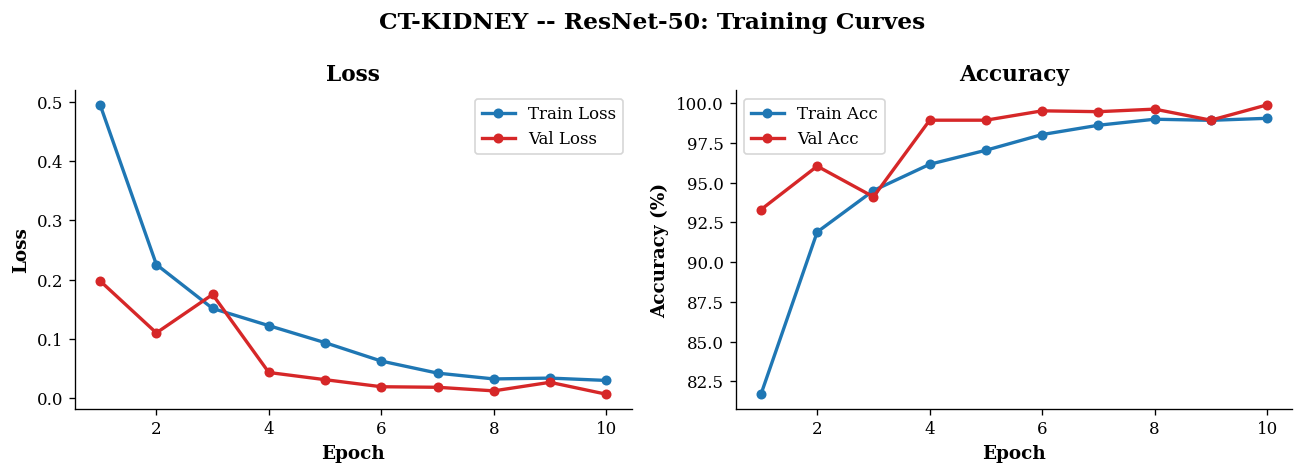

Testing ResNet-50:   0%|          | 0/117 [00:00<?, ?it/s]


----------------------------------------------------------------------
CT-KIDNEY -- ResNet-50: TEST RESULTS
----------------------------------------------------------------------
Accuracy : 99.73%
Precision (macro): 0.9965  |  Recall (macro): 0.9955  |  F1 (macro): 0.9960
Params: 24.56M  |  Inference: 4.956 ms/image
              precision    recall  f1-score   support

      Normal     0.9974    1.0000    0.9987       762
        Cyst     0.9982    0.9964    0.9973       556
       Tumor     1.0000    1.0000    1.0000       343
       Stone     0.9902    0.9854    0.9878       206

    accuracy                         0.9973      1867
   macro avg     0.9965    0.9955    0.9960      1867
weighted avg     0.9973    0.9973    0.9973      1867



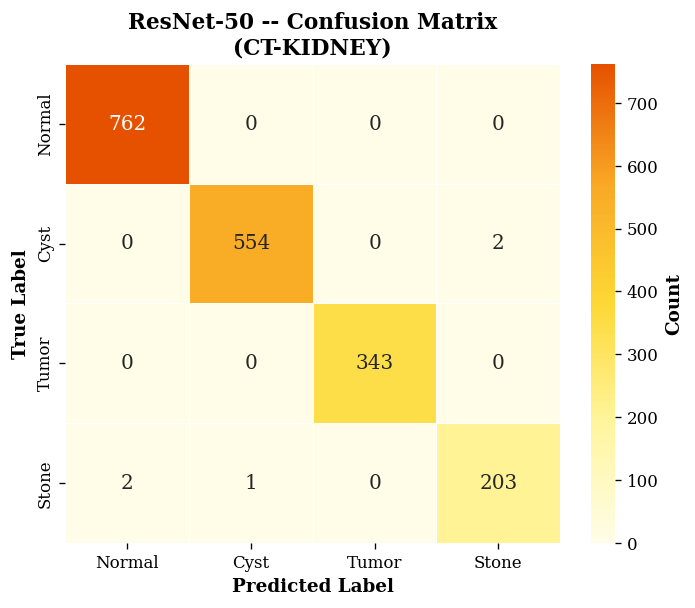


Per-class metrics: CT-KIDNEY -- ResNet-50


,Class,Precision,Recall,F1-Score,Support
0,Normal,0.9974,1.0000,0.9987,762
1,Cyst,0.9982,0.9964,0.9973,556
2,Tumor,1.0000,1.0000,1.0000,343
3,Stone,0.9902,0.9854,0.9878,206



TRAINING: CT-KIDNEY__VGG-16  (checkpoint metric: val_loss)


Training:   0%|          | 0/545 [00:00<?, ?it/s]

Validation:   0%|          | 0/117 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 9/10 (197.3s) | train_loss=0.0049 train_acc=99.87% | val_loss=0.0040 val_acc=99.89%  <- best


Training:   0%|          | 0/545 [00:00<?, ?it/s]

Validation:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 10/10 (196.7s) | train_loss=0.0069 train_acc=99.79% | val_loss=0.0028 val_acc=99.84%  <- best
Best val_loss: 0.0028  (checkpoint: checkpoints\CT-KIDNEY__VGG-16.pt)


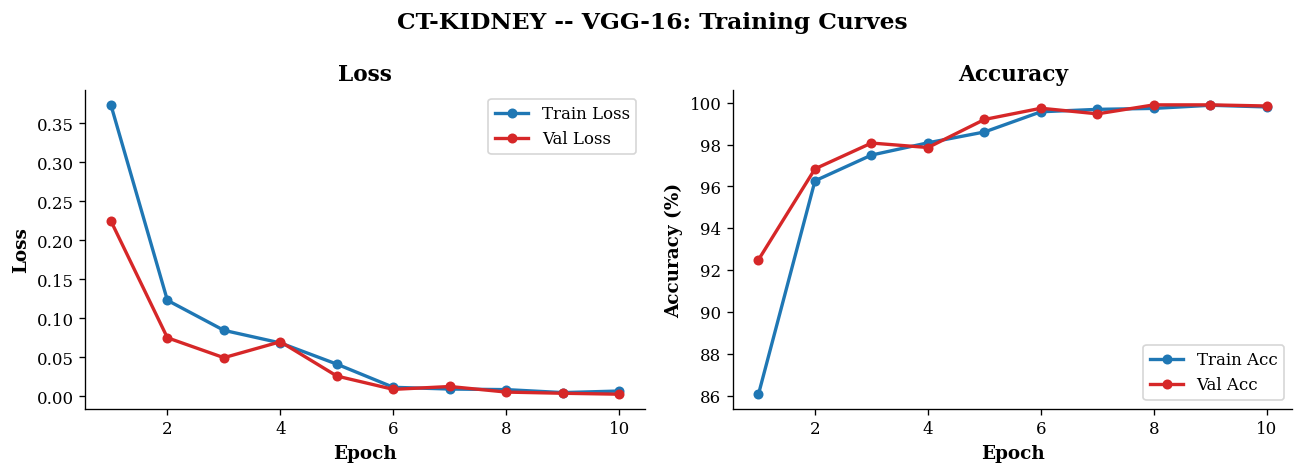

Testing VGG-16:   0%|          | 0/117 [00:00<?, ?it/s]


----------------------------------------------------------------------
CT-KIDNEY -- VGG-16: TEST RESULTS
----------------------------------------------------------------------
Accuracy : 99.95%
Precision (macro): 0.9988  |  Recall (macro): 0.9996  |  F1 (macro): 0.9992
Params: 121.68M  |  Inference: 4.770 ms/image
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000       762
        Cyst     1.0000    0.9982    0.9991       556
       Tumor     1.0000    1.0000    1.0000       343
       Stone     0.9952    1.0000    0.9976       206

    accuracy                         0.9995      1867
   macro avg     0.9988    0.9996    0.9992      1867
weighted avg     0.9995    0.9995    0.9995      1867



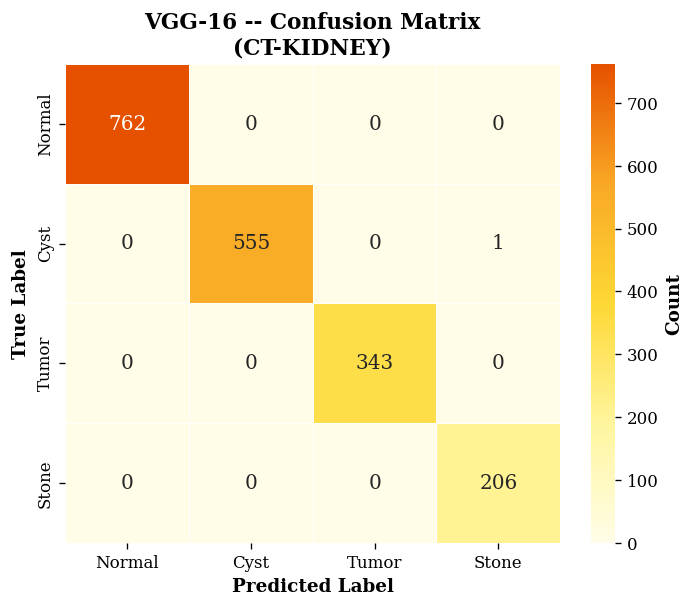


Per-class metrics: CT-KIDNEY -- VGG-16


,Class,Precision,Recall,F1-Score,Support
0,Normal,1.0000,1.0000,1.0000,762
1,Cyst,1.0000,0.9982,0.9991,556
2,Tumor,1.0000,1.0000,1.0000,343
3,Stone,0.9952,1.0000,0.9976,206



TRAINING: CT-KIDNEY__MUL-CNN  (checkpoint metric: val_loss)


Training:   0%|          | 0/545 [00:00<?, ?it/s]

Validation:   0%|          | 0/117 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 9/10 (173.8s) | train_loss=0.0965 train_acc=96.79% | val_loss=0.0418 val_acc=98.02%


Training:   0%|          | 0/545 [00:00<?, ?it/s]

Validation:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 10/10 (174.3s) | train_loss=0.0853 train_acc=97.16% | val_loss=0.0283 val_acc=98.98%  <- best
Best val_loss: 0.0283  (checkpoint: checkpoints\CT-KIDNEY__MUL-CNN.pt)


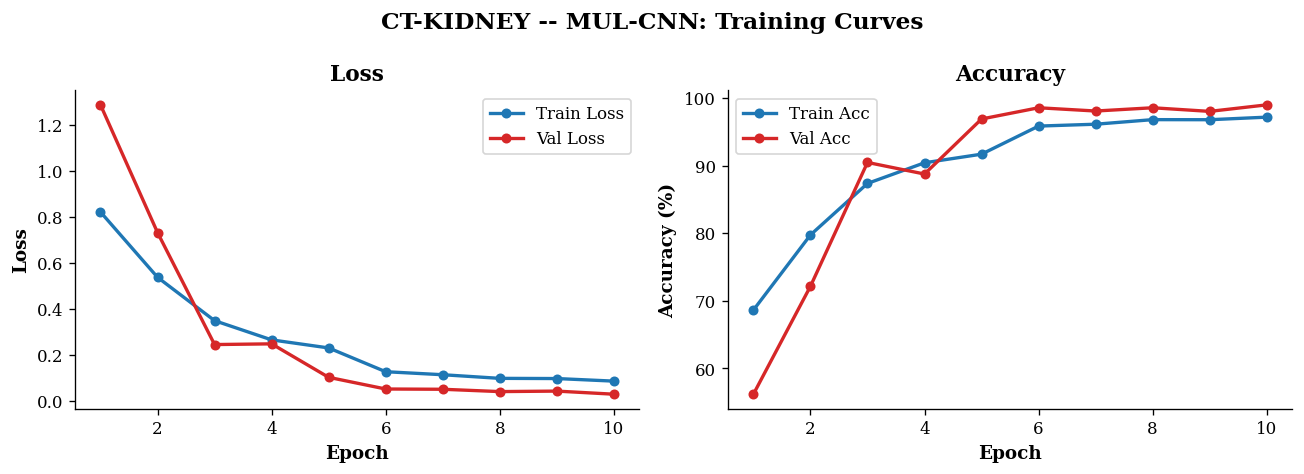

Testing MUL-CNN:   0%|          | 0/117 [00:00<?, ?it/s]


----------------------------------------------------------------------
CT-KIDNEY -- MUL-CNN: TEST RESULTS
----------------------------------------------------------------------
Accuracy : 99.09%
Precision (macro): 0.9884  |  Recall (macro): 0.9865  |  F1 (macro): 0.9874
Params: 2.95M  |  Inference: 4.225 ms/image
              precision    recall  f1-score   support

      Normal     0.9935    0.9987    0.9961       762
        Cyst     0.9892    0.9910    0.9901       556
       Tumor     1.0000    0.9854    0.9927       343
       Stone     0.9709    0.9709    0.9709       206

    accuracy                         0.9909      1867
   macro avg     0.9884    0.9865    0.9874      1867
weighted avg     0.9909    0.9909    0.9909      1867



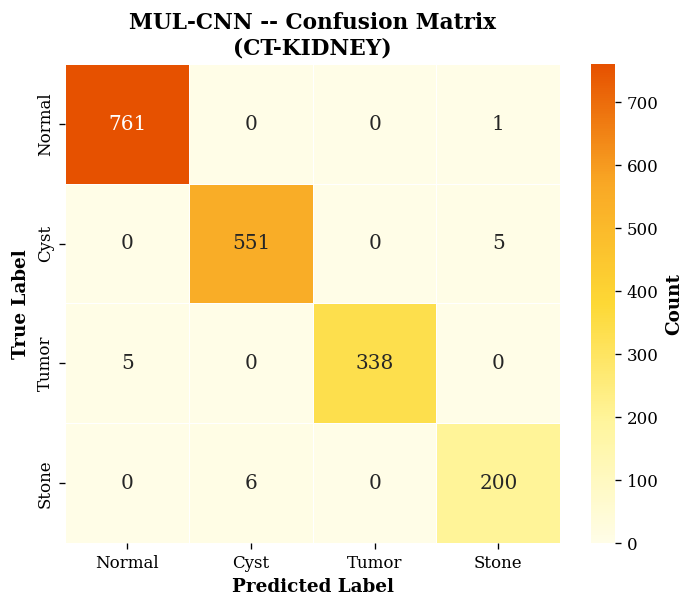


Per-class metrics: CT-KIDNEY -- MUL-CNN


,Class,Precision,Recall,F1-Score,Support
0,Normal,0.9935,0.9987,0.9961,762
1,Cyst,0.9892,0.9910,0.9901,556
2,Tumor,1.0000,0.9854,0.9927,343
3,Stone,0.9709,0.9709,0.9709,206



TRAINING: RenSeg-KidneyCT__ResNet-50  (checkpoint metric: val_acc)


Training:   0%|          | 0/383 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 9/10 (124.5s) | train_loss=0.0021 train_acc=99.95% | val_loss=0.0005 val_acc=100.00%


Training:   0%|          | 0/383 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 10/10 (121.0s) | train_loss=0.0073 train_acc=99.79% | val_loss=0.0040 val_acc=99.77%
Best val_acc: 100.0000  (checkpoint: checkpoints\RenSeg-KidneyCT__ResNet-50.pt)


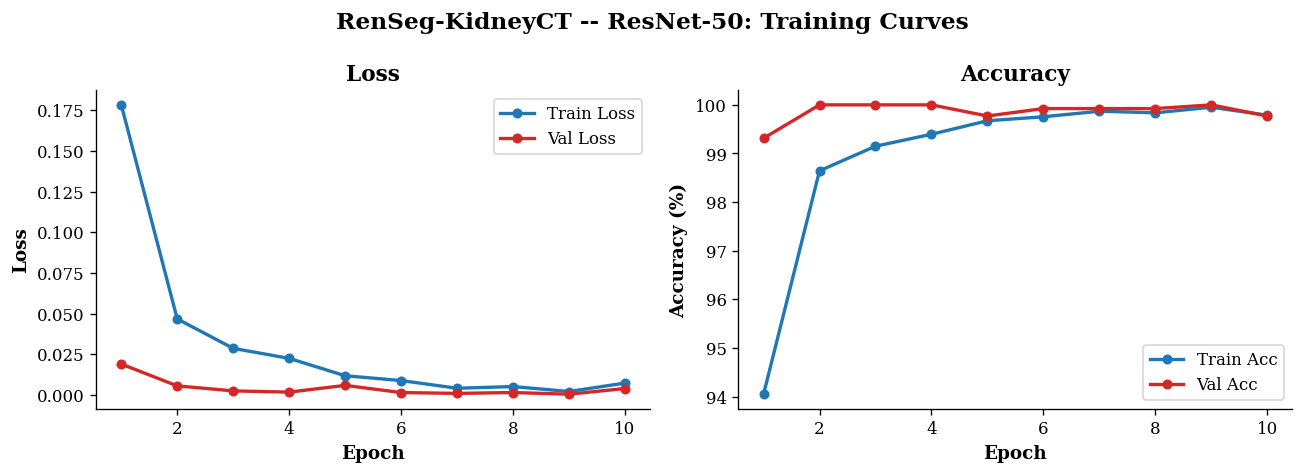

Testing ResNet-50:   0%|          | 0/82 [00:00<?, ?it/s]


----------------------------------------------------------------------
RenSeg-KidneyCT -- ResNet-50: TEST RESULTS
----------------------------------------------------------------------
Accuracy : 99.77%
Precision (macro): 0.9958  |  Recall (macro): 0.9964  |  F1 (macro): 0.9961
Params: 24.56M  |  Inference: 4.382 ms/image
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000       762
       Stone     0.9904    0.9952    0.9928       207
       Tumor     0.9971    0.9942    0.9956       342

    accuracy                         0.9977      1311
   macro avg     0.9958    0.9964    0.9961      1311
weighted avg     0.9977    0.9977    0.9977      1311



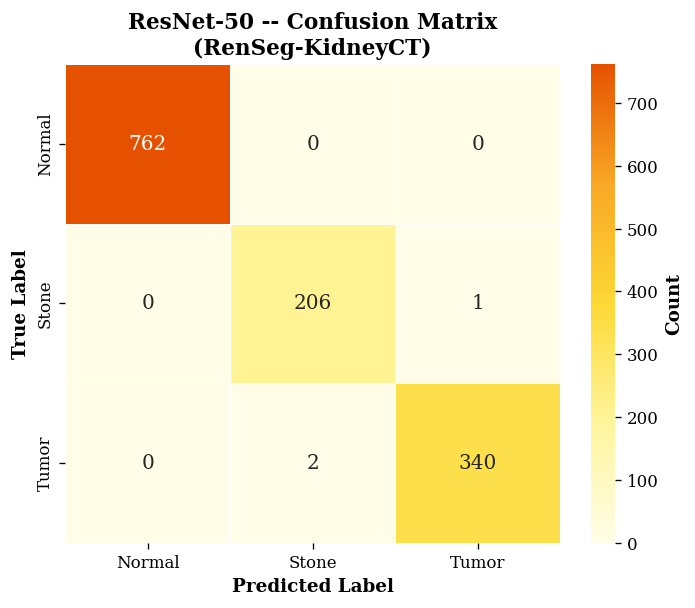


Per-class metrics: RenSeg-KidneyCT -- ResNet-50


,Class,Precision,Recall,F1-Score,Support
0,Normal,1.0000,1.0000,1.0000,762
1,Stone,0.9904,0.9952,0.9928,207
2,Tumor,0.9971,0.9942,0.9956,342



TRAINING: RenSeg-KidneyCT__VGG-16  (checkpoint metric: val_acc)


Training:   0%|          | 0/383 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 9/10 (135.7s) | train_loss=0.0008 train_acc=99.98% | val_loss=0.0007 val_acc=100.00%


Training:   0%|          | 0/383 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 10/10 (136.5s) | train_loss=0.0021 train_acc=99.95% | val_loss=0.0006 val_acc=100.00%
Best val_acc: 100.0000  (checkpoint: checkpoints\RenSeg-KidneyCT__VGG-16.pt)


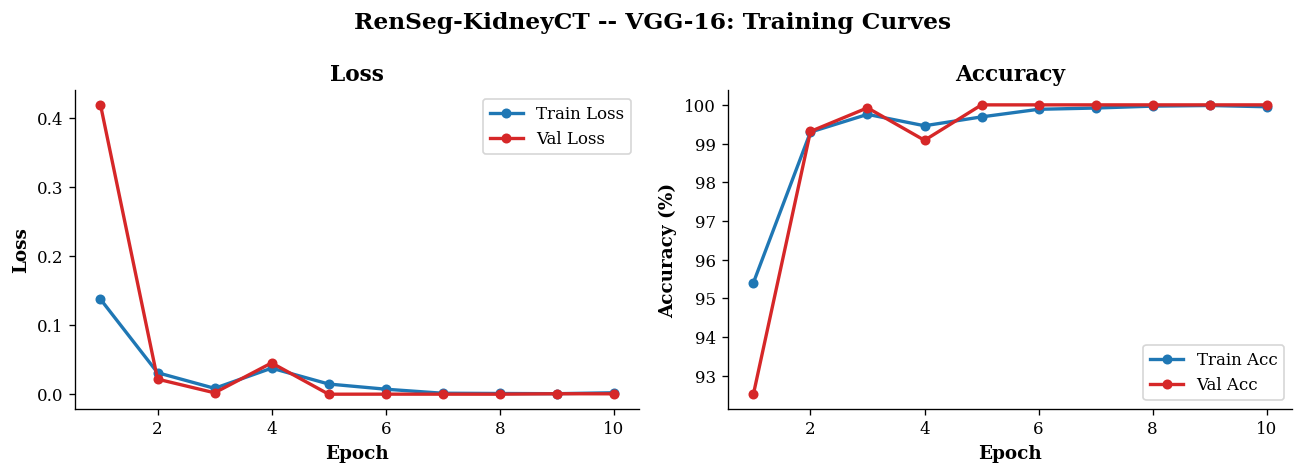

Testing VGG-16:   0%|          | 0/82 [00:00<?, ?it/s]


----------------------------------------------------------------------
RenSeg-KidneyCT -- VGG-16: TEST RESULTS
----------------------------------------------------------------------
Accuracy : 100.00%
Precision (macro): 1.0000  |  Recall (macro): 1.0000  |  F1 (macro): 1.0000
Params: 121.68M  |  Inference: 4.736 ms/image
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000       762
       Stone     1.0000    1.0000    1.0000       207
       Tumor     1.0000    1.0000    1.0000       342

    accuracy                         1.0000      1311
   macro avg     1.0000    1.0000    1.0000      1311
weighted avg     1.0000    1.0000    1.0000      1311



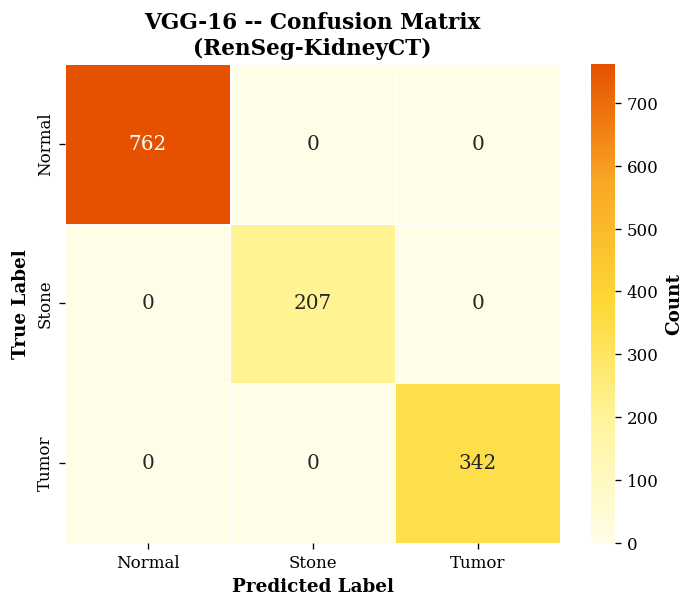


Per-class metrics: RenSeg-KidneyCT -- VGG-16


,Class,Precision,Recall,F1-Score,Support
0,Normal,1.0,1.0,1.0,762
1,Stone,1.0,1.0,1.0,207
2,Tumor,1.0,1.0,1.0,342



TRAINING: RenSeg-KidneyCT__MUL-CNN  (checkpoint metric: val_acc)


Training:   0%|          | 0/383 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 9/10 (123.1s) | train_loss=0.0062 train_acc=99.89% | val_loss=0.0007 val_acc=100.00%


Training:   0%|          | 0/383 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 10/10 (125.7s) | train_loss=0.0148 train_acc=99.82% | val_loss=0.0006 val_acc=100.00%
Best val_acc: 100.0000  (checkpoint: checkpoints\RenSeg-KidneyCT__MUL-CNN.pt)


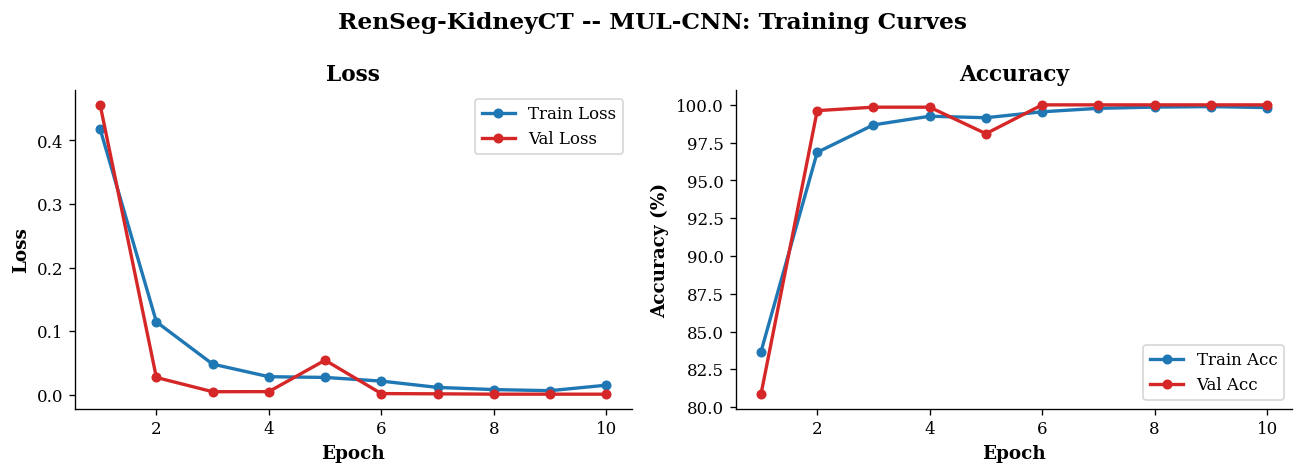

Testing MUL-CNN:   0%|          | 0/82 [00:00<?, ?it/s]


----------------------------------------------------------------------
RenSeg-KidneyCT -- MUL-CNN: TEST RESULTS
----------------------------------------------------------------------
Accuracy : 99.92%
Precision (macro): 0.9996  |  Recall (macro): 0.9984  |  F1 (macro): 0.9990
Params: 2.95M  |  Inference: 4.949 ms/image
              precision    recall  f1-score   support

      Normal     0.9987    1.0000    0.9993       762
       Stone     1.0000    0.9952    0.9976       207
       Tumor     1.0000    1.0000    1.0000       342

    accuracy                         0.9992      1311
   macro avg     0.9996    0.9984    0.9990      1311
weighted avg     0.9992    0.9992    0.9992      1311



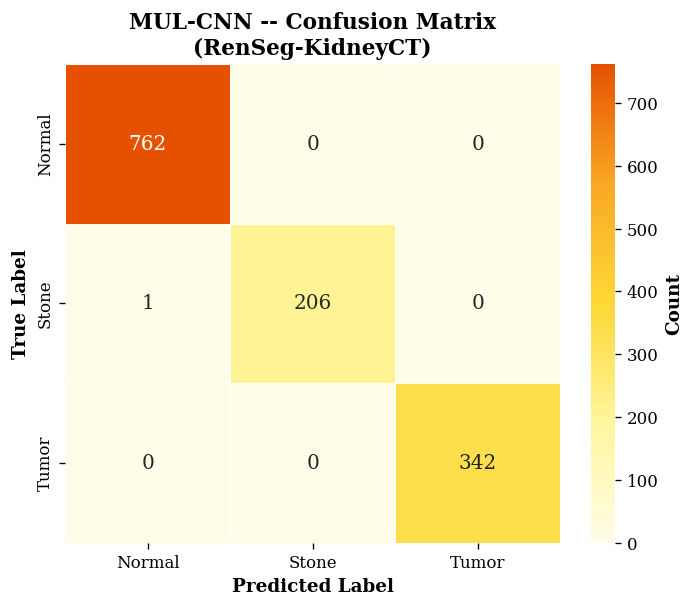


Per-class metrics: RenSeg-KidneyCT -- MUL-CNN


,Class,Precision,Recall,F1-Score,Support
0,Normal,0.9987,1.0000,0.9993,762
1,Stone,1.0000,0.9952,0.9976,207
2,Tumor,1.0000,1.0000,1.0000,342



Primary experiments complete for all datasets/models.
Trained models are kept in ALL_MODELS for reuse by Grad-CAM (Section 15).
If memory is tight, model weights can also be reloaded later from ALL_CKPT_PATHS.


In [17]:
ALL_MODELS = {dkey: {} for dkey in DATASETS_CFG}          # trained nn.Module objects (kept in memory for Grad-CAM)
ALL_RESULTS = {dkey: {} for dkey in DATASETS_CFG}
ALL_HISTORIES = {dkey: {} for dkey in DATASETS_CFG}
ALL_PERCLASS_TABLES = {dkey: {} for dkey in DATASETS_CFG}
ALL_CKPT_PATHS = {dkey: {} for dkey in DATASETS_CFG}

for _dkey, _dcfg in DATASETS_CFG.items():
    for _mname in GLOBAL_CFG['primary_models']:
        set_seed(SEED)   # re-seed before every training run for full reproducibility
        _model = build_model(_mname, _dcfg['num_classes'])
        _model, _history, _ckpt = train_model(
            _model, LOADERS[_dkey], _dkey, model_tag=f'{_dkey}__{_mname}',
            checkpoint_metric=_dcfg['checkpoint_metric'])
        plot_training_curves(_history, _dkey, _mname)

        _result = evaluate_model(_model, LOADERS[_dkey]['test'], _dkey, _mname)
        ALL_MODELS[_dkey][_mname] = _model
        ALL_RESULTS[_dkey][_mname] = _result
        ALL_HISTORIES[_dkey][_mname] = _history
        ALL_CKPT_PATHS[_dkey][_mname] = _ckpt
        ALL_PERCLASS_TABLES[_dkey][_mname] = per_class_metrics_table(_result)

        gc.collect()
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

print("\nPrimary experiments complete for all datasets/models.")
print("Trained models are kept in ALL_MODELS for reuse by Grad-CAM (Section 15).")
print("If memory is tight, model weights can also be reloaded later from ALL_CKPT_PATHS.")


---
## 13. Statistical Analysis

The primary results (Section 12) report point-estimate accuracy/F1 values
that sometimes differ by less than one percentage point. Without statistical
testing, a reviewer can reasonably question whether such differences are
meaningful or within noise given test sets of order 1,300-1,900 images. Two
tests are added here, **both computed directly from the predictions already
produced in Section 12 -- no retraining required:**

1. **McNemar's test** (paired, for classifier comparison on the same test
   set) between every pair of primary models, per dataset -- tests whether
   one model's errors are significantly different in number from another's
   on the *same* test images.
2. **Bootstrap 95% confidence intervals** for accuracy and macro F1 (2,000
   resamples of the test set with replacement) for every model -- gives an
   uncertainty range around each point estimate, so a reader can judge at a
   glance whether two intervals overlap.


In [18]:
def mcnemar_test(labels, preds_a, preds_b):
    """McNemar's test (with continuity correction) for two classifiers evaluated
    on the same test set. Returns (statistic, p_value, n01, n10) where n01/n10 are
    the discordant-pair counts (a wrong & b right / a right & b wrong)."""
    correct_a = (preds_a == labels)
    correct_b = (preds_b == labels)
    n01 = int(np.sum((~correct_a) & correct_b))   # a wrong, b right
    n10 = int(np.sum(correct_a & (~correct_b)))   # a right, b wrong
    n_discordant = n01 + n10
    if n_discordant == 0:
        return 0.0, 1.0, n01, n10
    if n_discordant < 25:
        # exact binomial test is more reliable with few discordant pairs
        p_value = 2 * scipy_stats.binom.cdf(min(n01, n10), n_discordant, 0.5)
        p_value = min(p_value, 1.0)
        stat = float(min(n01, n10))
    else:
        stat = (abs(n01 - n10) - 1) ** 2 / n_discordant   # continuity-corrected chi-square
        p_value = 1 - scipy_stats.chi2.cdf(stat, df=1)
    return float(stat), float(p_value), n01, n10


def bootstrap_ci(labels, preds, metric='accuracy', n_boot=2000, seed=SEED, alpha=0.05):
    """Percentile-method bootstrap confidence interval for accuracy or macro F1."""
    rng = np.random.RandomState(seed)
    n = len(labels)
    scores = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.randint(0, n, n)
        if metric == 'accuracy':
            scores[i] = accuracy_score(labels[idx], preds[idx])
        elif metric == 'f1_macro':
            scores[i] = f1_score(labels[idx], preds[idx], average='macro', zero_division=0)
        else:
            raise ValueError(metric)
    lo, hi = np.percentile(scores, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(scores.mean()), float(lo), float(hi)


In [19]:
# ----------------------------------------------------------------------------
# 13.1 Pairwise McNemar's tests (per dataset, across the primary models)
# ----------------------------------------------------------------------------
MCNEMAR_RESULTS = {}
for _dkey in DATASETS_CFG:
    print(f"\n{'='*78}\nMcNEMAR PAIRWISE TESTS: {_dkey}\n{'='*78}")
    _models = GLOBAL_CFG['primary_models']
    _rows = []
    for i in range(len(_models)):
        for j in range(i + 1, len(_models)):
            m_a, m_b = _models[i], _models[j]
            res_a, res_b = ALL_RESULTS[_dkey][m_a], ALL_RESULTS[_dkey][m_b]
            assert np.array_equal(res_a['labels'], res_b['labels']), "Test sets must match for a valid McNemar test"
            stat, p, n01, n10 = mcnemar_test(res_a['labels'], res_a['predictions'], res_b['predictions'])
            significant = p < 0.05
            _rows.append({
                'Model A': m_a, 'Model B': m_b,
                'Acc. A (%)': f"{res_a['accuracy']*100:.2f}", 'Acc. B (%)': f"{res_b['accuracy']*100:.2f}",
                'Discordant (A-wrong/B-right)': n01, 'Discordant (A-right/B-wrong)': n10,
                'Statistic': round(stat, 3), 'p-value': round(p, 4),
                'Significant (p<0.05)': 'Yes' if significant else 'No',
            })
    df = pd.DataFrame(_rows)
    MCNEMAR_RESULTS[_dkey] = df
    display(df)



McNEMAR PAIRWISE TESTS: CT-KIDNEY


,Model A,Model B,Acc. A (%),Acc. B (%),Discordant (A-wrong/B-right),Discordant (A-right/B-wrong),Statistic,p-value,Significant (p<0.05)
0,ResNet-50,VGG-16,99.73,99.95,5,1,1.0,0.2188,No
1,ResNet-50,MUL-CNN,99.73,99.09,5,17,5.0,0.0169,Yes
2,VGG-16,MUL-CNN,99.95,99.09,1,17,1.0,0.0001,Yes



McNEMAR PAIRWISE TESTS: RenSeg-KidneyCT


,Model A,Model B,Acc. A (%),Acc. B (%),Discordant (A-wrong/B-right),Discordant (A-right/B-wrong),Statistic,p-value,Significant (p<0.05)
0,ResNet-50,VGG-16,99.77,100.00,3,0,0.0,0.250,No
1,ResNet-50,MUL-CNN,99.77,99.92,3,1,1.0,0.625,No
2,VGG-16,MUL-CNN,100.00,99.92,0,1,0.0,1.000,No


In [20]:
# ----------------------------------------------------------------------------
# 13.2 Bootstrap 95% confidence intervals (per dataset, per model)
# ----------------------------------------------------------------------------
BOOTSTRAP_CI_RESULTS = {}
for _dkey in DATASETS_CFG:
    print(f"\n{'='*78}\nBOOTSTRAP 95% CONFIDENCE INTERVALS: {_dkey}  (n_boot=2000)\n{'='*78}")
    _rows = []
    for _mname in GLOBAL_CFG['primary_models']:
        res = ALL_RESULTS[_dkey][_mname]
        acc_mean, acc_lo, acc_hi = bootstrap_ci(res['labels'], res['predictions'], metric='accuracy')
        f1_mean, f1_lo, f1_hi = bootstrap_ci(res['labels'], res['predictions'], metric='f1_macro')
        _rows.append({
            'Model': _mname,
            'Accuracy (%)': f"{acc_mean*100:.2f}",
            'Accuracy 95% CI': f"[{acc_lo*100:.2f}, {acc_hi*100:.2f}]",
            'Macro F1': f"{f1_mean:.4f}",
            'Macro F1 95% CI': f"[{f1_lo:.4f}, {f1_hi:.4f}]",
        })
    df = pd.DataFrame(_rows)
    BOOTSTRAP_CI_RESULTS[_dkey] = df
    display(df)



BOOTSTRAP 95% CONFIDENCE INTERVALS: CT-KIDNEY  (n_boot=2000)


,Model,Accuracy (%),Accuracy 95% CI,Macro F1,Macro F1 95% CI
0,ResNet-50,99.73,"[99.46, 99.95]",0.9959,"[0.9922, 0.9992]"
1,VGG-16,99.95,"[99.84, 100.00]",0.9992,"[0.9974, 1.0000]"
2,MUL-CNN,99.09,"[98.66, 99.52]",0.9874,"[0.9812, 0.9930]"



BOOTSTRAP 95% CONFIDENCE INTERVALS: RenSeg-KidneyCT  (n_boot=2000)


,Model,Accuracy (%),Accuracy 95% CI,Macro F1,Macro F1 95% CI
0,ResNet-50,99.78,"[99.47, 100.00]",0.9962,"[0.9912, 1.0000]"
1,VGG-16,100.00,"[100.00, 100.00]",1.0000,"[1.0000, 1.0000]"
2,MUL-CNN,99.92,"[99.77, 100.00]",0.9989,"[0.9967, 1.0000]"


---
## 14. Robustness

Two complementary robustness checks, both centred on **MUL-CNN** since it is
the paper's central contribution and the one whose stability across
conditions matters most to the paper's claims.

**14.1 -- Multi-seed robustness.** MUL-CNN is retrained from scratch with
two additional random seeds (`GLOBAL_CFG['seed_robustness_extra_seeds']`),
giving three independent training runs in total per dataset (seeds 42, 7,
123). Reporting **mean +/- standard deviation** across seeds, rather than a
single run's point estimate, is the standard way to show a result is not a
lucky initialisation -- this directly strengthens the paper's central
architecture claim.

**14.2 -- Perturbation robustness.** The already-trained primary models
(Section 12) are re-evaluated on the test set after three synthetic,
acquisition-style corruptions -- Gaussian noise, brightness shift, and
Gaussian blur -- applied at inference time only (no retraining). This
simulates the kind of scanner/acquisition variability a deployed model would
actually face, and is a cheap, standard way to probe generalisation beyond a
single clean test split.


In [21]:
# ----------------------------------------------------------------------------
# 14.1 Multi-seed robustness check for MUL-CNN
# ----------------------------------------------------------------------------
SEED_ROBUSTNESS_RESULTS = {dkey: {} for dkey in DATASETS_CFG}

if GLOBAL_CFG['run_seed_robustness']:
    _all_seeds = [SEED] + GLOBAL_CFG['seed_robustness_extra_seeds']
    for _dkey, _dcfg in DATASETS_CFG.items():
        print(f"\n{'='*78}\nMULTI-SEED ROBUSTNESS: MUL-CNN on {_dkey}  (seeds={_all_seeds})\n{'='*78}")
        for _seed in _all_seeds:
            if _seed == SEED and 'MUL-CNN' in ALL_RESULTS[_dkey]:
                # Reuse the primary-run result at the base seed instead of retraining --
                # it was already trained with set_seed(SEED) immediately beforehand in Section 12.
                SEED_ROBUSTNESS_RESULTS[_dkey][_seed] = ALL_RESULTS[_dkey]['MUL-CNN']
                print(f"  seed={_seed}: reusing primary MUL-CNN run "
                      f"(acc={ALL_RESULTS[_dkey]['MUL-CNN']['accuracy']*100:.2f}%)")
                continue
            set_seed(_seed)
            _model = build_model('MUL-CNN', _dcfg['num_classes'])
            _model, _history, _ckpt = train_model(
                _model, LOADERS[_dkey], _dkey, model_tag=f'{_dkey}__MUL-CNN__seed{_seed}',
                checkpoint_metric=_dcfg['checkpoint_metric'], verbose=False)
            _result = evaluate_model(_model, LOADERS[_dkey]['test'], _dkey,
                                      f'MUL-CNN (seed {_seed})', plot=False)
            SEED_ROBUSTNESS_RESULTS[_dkey][_seed] = _result
            print(f"  seed={_seed}: acc={_result['accuracy']*100:.2f}%  "
                  f"macro-F1={_result['f1_score']:.4f}")
            del _model
            gc.collect()
            torch.cuda.empty_cache() if torch.cuda.is_available() else None
else:
    print("Multi-seed robustness disabled (GLOBAL_CFG['run_seed_robustness'] = False).")



MULTI-SEED ROBUSTNESS: MUL-CNN on CT-KIDNEY  (seeds=[42, 7, 123])
  seed=42: reusing primary MUL-CNN run (acc=99.09%)


Training:   0%|          | 0/545 [00:00<?, ?it/s]

Validation:   0%|          | 0/117 [00:00<?, ?it/s]

Training:   0%|          | 0/545 [00:00<?, ?it/s]

Validation:   0%|          | 0/117 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

Training:   0%|          | 0/383 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

Testing MUL-CNN (seed 123):   0%|          | 0/82 [00:00<?, ?it/s]


----------------------------------------------------------------------
RenSeg-KidneyCT -- MUL-CNN (seed 123): TEST RESULTS
----------------------------------------------------------------------
Accuracy : 99.92%
Precision (macro): 0.9996  |  Recall (macro): 0.9984  |  F1 (macro): 0.9990
Params: 2.95M  |  Inference: 4.086 ms/image
              precision    recall  f1-score   support

      Normal     0.9987    1.0000    0.9993       762
       Stone     1.0000    0.9952    0.9976       207
       Tumor     1.0000    1.0000    1.0000       342

    accuracy                         0.9992      1311
   macro avg     0.9996    0.9984    0.9990      1311
weighted avg     0.9992    0.9992    0.9992      1311

  seed=123: acc=99.92%  macro-F1=0.9990


In [22]:
# ----------------------------------------------------------------------------
# 14.1 (cont.) Mean +/- std summary across seeds
# ----------------------------------------------------------------------------
SEED_ROBUSTNESS_SUMMARY = {}
if GLOBAL_CFG['run_seed_robustness']:
    _rows = []
    for _dkey in DATASETS_CFG:
        _accs = np.array([r['accuracy'] for r in SEED_ROBUSTNESS_RESULTS[_dkey].values()]) * 100
        _f1s = np.array([r['f1_score'] for r in SEED_ROBUSTNESS_RESULTS[_dkey].values()])
        _rows.append({
            'Dataset': _dkey,
            'Seeds': list(SEED_ROBUSTNESS_RESULTS[_dkey].keys()),
            'Accuracy (%) mean +/- std': f"{_accs.mean():.2f} +/- {_accs.std():.2f}",
            'Accuracy (%) range': f"[{_accs.min():.2f}, {_accs.max():.2f}]",
            'Macro F1 mean +/- std': f"{_f1s.mean():.4f} +/- {_f1s.std():.4f}",
        })
    SEED_ROBUSTNESS_SUMMARY = pd.DataFrame(_rows)
    print("MUL-CNN multi-seed robustness summary:")
    display(SEED_ROBUSTNESS_SUMMARY)


MUL-CNN multi-seed robustness summary:


,Dataset,Seeds,Accuracy (%) mean +/- std,Accuracy (%) range,Macro F1 mean +/- std
0,CT-KIDNEY,"[42, 7, 123]",98.82 +/- 0.19,"[98.66, 99.09]",0.9842 +/- 0.0023
1,RenSeg-KidneyCT,"[42, 7, 123]",99.92 +/- 0.00,"[99.92, 99.92]",0.9990 +/- 0.0000


### 14.2 Perturbation robustness stress test

Three corruptions are applied directly to the (already ImageNet-normalised)
test-set tensors at inference time:
- **Gaussian noise** -- additive noise with std 0.05 in normalised pixel
  space, simulating sensor/quantum noise.
- **Brightness shift** -- a fixed intensity offset, simulating differing
  scanner calibration or windowing.
- **Gaussian blur** -- a 5x5 blur kernel, simulating motion or reduced
  acquisition resolution.

Each of the three primary models, on both datasets, is evaluated under each
corruption using the exact same trained weights from Section 12 -- **no
retraining**, purely inference-time perturbation.


In [23]:
# ----------------------------------------------------------------------------
# 14.2 Perturbation robustness stress test
# ----------------------------------------------------------------------------
import torchvision.transforms.functional as TF

def _add_gaussian_noise(tensor, std=0.05):
    return tensor + torch.randn_like(tensor) * std

def _shift_brightness(tensor, delta=0.15):
    return tensor + delta

def _gaussian_blur(tensor, kernel_size=5, sigma=1.5):
    return TF.gaussian_blur(tensor, kernel_size=[kernel_size, kernel_size], sigma=[sigma, sigma])

PERTURBATIONS = {
    'Clean (no perturbation)': lambda x: x,
    'Gaussian Noise (std=0.05)': _add_gaussian_noise,
    'Brightness Shift (+0.15)': _shift_brightness,
    'Gaussian Blur (k=5, sigma=1.5)': _gaussian_blur,
}


def evaluate_under_perturbation(model, test_loader, perturb_fn, device):
    """Same accuracy computation as evaluate_model(), but with a perturbation
    applied to each batch of already-loaded (resized, normalised) tensors before
    the forward pass. No re-loading or re-augmenting from disk is needed."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = perturb_fn(inputs).to(device)
            outputs = model(inputs)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds, average='macro', zero_division=0)


PERTURBATION_RESULTS = {dkey: {} for dkey in DATASETS_CFG}
if GLOBAL_CFG['run_perturbation_robustness']:
    for _dkey in DATASETS_CFG:
        print(f"\n{'='*78}\nPERTURBATION ROBUSTNESS: {_dkey}\n{'='*78}")
        _rows = []
        for _mname in GLOBAL_CFG['primary_models']:
            _model = ALL_MODELS[_dkey][_mname]
            _row = {'Model': _mname}
            for _pname, _pfn in PERTURBATIONS.items():
                _acc, _f1 = evaluate_under_perturbation(_model, LOADERS[_dkey]['test'], _pfn, DEVICE)
                _row[f'{_pname} - Acc (%)'] = round(_acc * 100, 2)
                _row[f'{_pname} - F1'] = round(_f1, 4)
            _rows.append(_row)
        df = pd.DataFrame(_rows)
        PERTURBATION_RESULTS[_dkey] = df
        display(df)
else:
    print("Perturbation robustness disabled (GLOBAL_CFG['run_perturbation_robustness'] = False).")



PERTURBATION ROBUSTNESS: CT-KIDNEY


,Model,Clean (no perturbation) - Acc (%),Clean (no perturbation) - F1,Gaussian Noise (std=0.05) - Acc (%),Gaussian Noise (std=0.05) - F1,Brightness Shift (+0.15) - Acc (%),Brightness Shift (+0.15) - F1,"Gaussian Blur (k=5, sigma=1.5) - Acc (%)","Gaussian Blur (k=5, sigma=1.5) - F1"
0,ResNet-50,99.73,0.9960,94.43,0.9323,99.57,0.9938,55.81,0.5107
1,VGG-16,99.95,0.9992,98.98,0.9862,99.95,0.9995,83.66,0.8145
2,MUL-CNN,99.09,0.9874,41.56,0.2771,98.50,0.9812,68.29,0.6415



PERTURBATION ROBUSTNESS: RenSeg-KidneyCT


,Model,Clean (no perturbation) - Acc (%),Clean (no perturbation) - F1,Gaussian Noise (std=0.05) - Acc (%),Gaussian Noise (std=0.05) - F1,Brightness Shift (+0.15) - Acc (%),Brightness Shift (+0.15) - F1,"Gaussian Blur (k=5, sigma=1.5) - Acc (%)","Gaussian Blur (k=5, sigma=1.5) - F1"
0,ResNet-50,99.77,0.9961,99.31,0.989,99.69,0.9948,91.99,0.8579
1,VGG-16,100.00,1.0000,99.92,0.999,100.00,1.0000,96.11,0.9435
2,MUL-CNN,99.92,0.9990,99.92,0.999,99.92,0.9990,99.62,0.9941


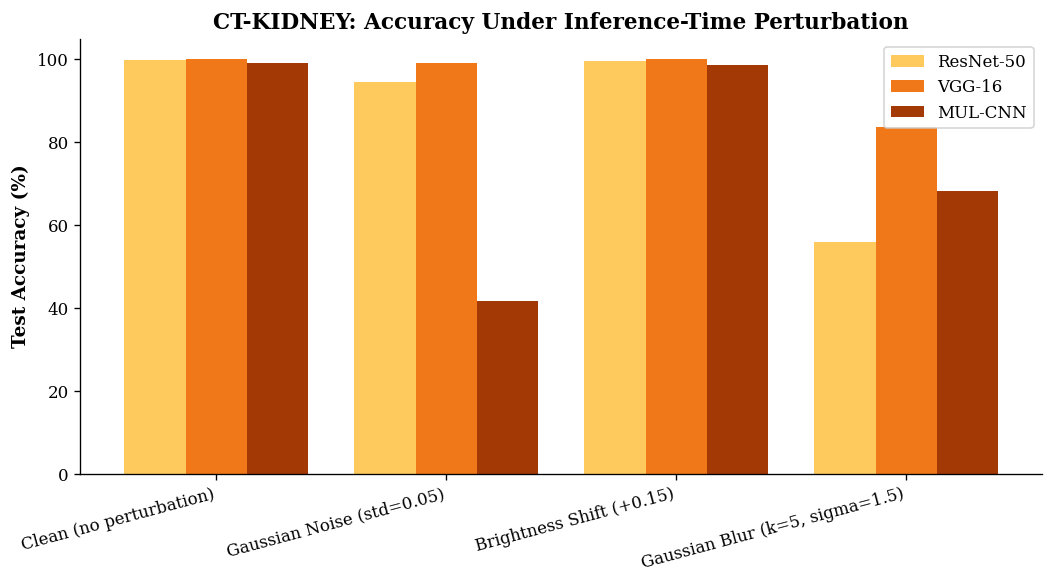

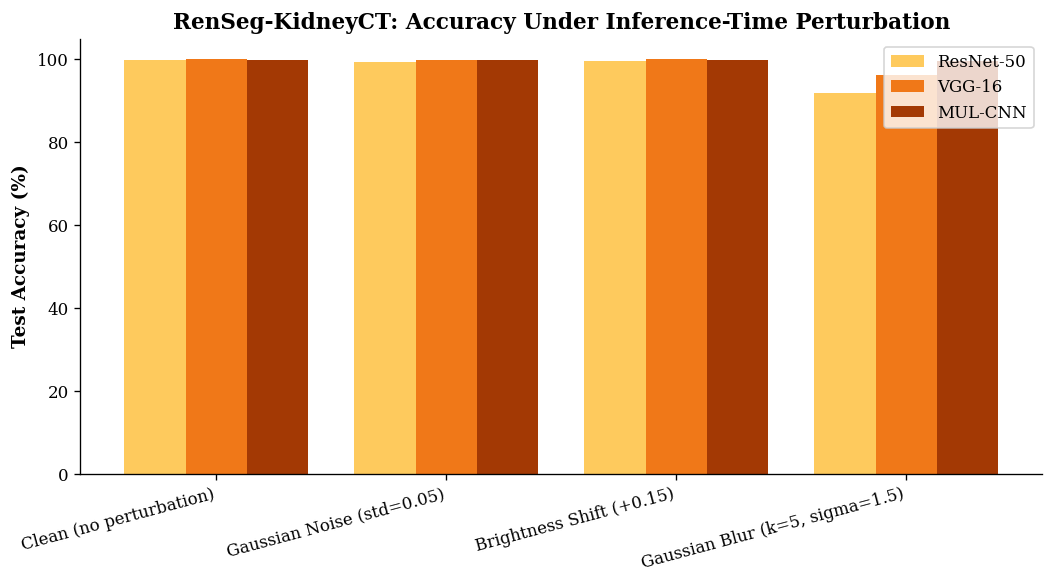

In [24]:
# ----------------------------------------------------------------------------
# 14.2 (cont.) Accuracy-drop-under-perturbation bar chart, per dataset
# ----------------------------------------------------------------------------
if GLOBAL_CFG['run_perturbation_robustness']:
    for _dkey in DATASETS_CFG:
        df = PERTURBATION_RESULTS[_dkey]
        _acc_cols = [c for c in df.columns if c.endswith('- Acc (%)')]
        _pert_names = [c.replace(' - Acc (%)', '') for c in _acc_cols]

        fig, ax = plt.subplots(figsize=(9, 5))
        _x = np.arange(len(_pert_names))
        _width = 0.8 / len(df)
        _colors = plt.cm.YlOrBr(np.linspace(0.35, 0.85, len(df)))
        for i, (_, row) in enumerate(df.iterrows()):
            _vals = [row[c] for c in _acc_cols]
            ax.bar(_x + i * _width, _vals, width=_width, label=row['Model'], color=_colors[i])

        ax.set_xticks(_x + _width * (len(df) - 1) / 2)
        ax.set_xticklabels(_pert_names, rotation=15, ha='right')
        ax.set_ylabel('Test Accuracy (%)')
        ax.set_title(f'{_dkey}: Accuracy Under Inference-Time Perturbation')
        ax.legend()
        fig.tight_layout()
        save_fig(fig, _dkey, 'perturbation_robustness')
        plt.show()


---
## 15. Explainability (Grad-CAM)

Grad-CAM (Selvaraju et al., 2017) heatmaps for **every primary model on both
datasets**, reusing the already-trained weights from Section 12 -- exactly
the workflow present in both original notebooks, generalised to run over any
dataset/model combination instead of being hand-written per model. For each
model, one correctly-classified test-set example per class is located, and
its original image, raw Grad-CAM heatmap, and overlay are plotted side by
side, matching the layout of the original notebooks.


In [25]:
# ----------------------------------------------------------------------------
# 15.1 Grad-CAM setup
# ----------------------------------------------------------------------------
if GLOBAL_CFG['run_gradcam']:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image

    def get_target_layer(model, model_name):
        """Return the Grad-CAM target layer(s) appropriate for each architecture."""
        if model_name == 'ResNet-50':
            return [model.layer4[-1]]
        if model_name == 'VGG-16':
            return [model.features[-1]]
        if model_name == 'MUL-CNN':
            # last conv block before the final pooling/GAP
            return [model.conv5b]
        raise ValueError(f"No Grad-CAM target layer configured for model '{model_name}'")


    def visualize_gradcam(model, model_name, dataset_key, test_dataset, num_samples_per_class=1):
        """Generate and save Grad-CAM heatmaps: one correctly-classified example
        per class, showing original / heatmap / overlay side by side."""
        cfg = DATASETS_CFG[dataset_key]
        class_names = cfg['class_names']
        num_classes = cfg['num_classes']
        model.eval()

        target_layers = get_target_layer(model, model_name)
        cam = GradCAM(model=model, target_layers=target_layers)

        samples_per_class = {i: [] for i in range(num_classes)}
        for idx in range(len(test_dataset)):
            if all(len(v) >= num_samples_per_class for v in samples_per_class.values()):
                break
            img, true_label = test_dataset[idx]
            img_input = img.unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                pred_label = model(img_input).argmax(1).item()
            if pred_label == true_label and len(samples_per_class[true_label]) < num_samples_per_class:
                samples_per_class[true_label].append((idx, img, true_label))

        fig, axes = plt.subplots(num_classes, 3, figsize=(12, 3.6 * num_classes))
        if num_classes == 1:
            axes = axes.reshape(1, 3)

        for class_idx in range(num_classes):
            if len(samples_per_class[class_idx]) == 0:
                for col in range(3):
                    axes[class_idx, col].axis('off')
                continue
            _, img, true_label = samples_per_class[class_idx][0]
            img_input = img.unsqueeze(0).to(DEVICE)

            grayscale_cam = cam(input_tensor=img_input, targets=None)[0, :]

            img_np = denormalize(img.clone()).permute(1, 2, 0).cpu().numpy()
            img_np = np.clip(img_np, 0, 1)
            cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

            axes[class_idx, 0].imshow(img_np)
            axes[class_idx, 0].set_title(f'Original -- {class_names[true_label]}', fontweight='bold')
            axes[class_idx, 0].axis('off')

            axes[class_idx, 1].imshow(grayscale_cam, cmap='jet')
            axes[class_idx, 1].set_title('Grad-CAM Heatmap', fontweight='bold')
            axes[class_idx, 1].axis('off')

            axes[class_idx, 2].imshow(cam_image)
            axes[class_idx, 2].set_title('Overlay', fontweight='bold')
            axes[class_idx, 2].axis('off')

        fig.suptitle(f'{dataset_key} -- {model_name}: Grad-CAM Visualizations', fontsize=15, fontweight='bold')
        fig.tight_layout()
        save_path = save_fig(fig, dataset_key, f'{model_name}_gradcam', also_pdf=False)
        plt.show()
        print(f"Saved: {save_path}")
        del cam
else:
    print("Grad-CAM disabled (GLOBAL_CFG['run_gradcam'] = False).")



GRAD-CAM: CT-KIDNEY

Generating Grad-CAM for ResNet-50 on CT-KIDNEY ...


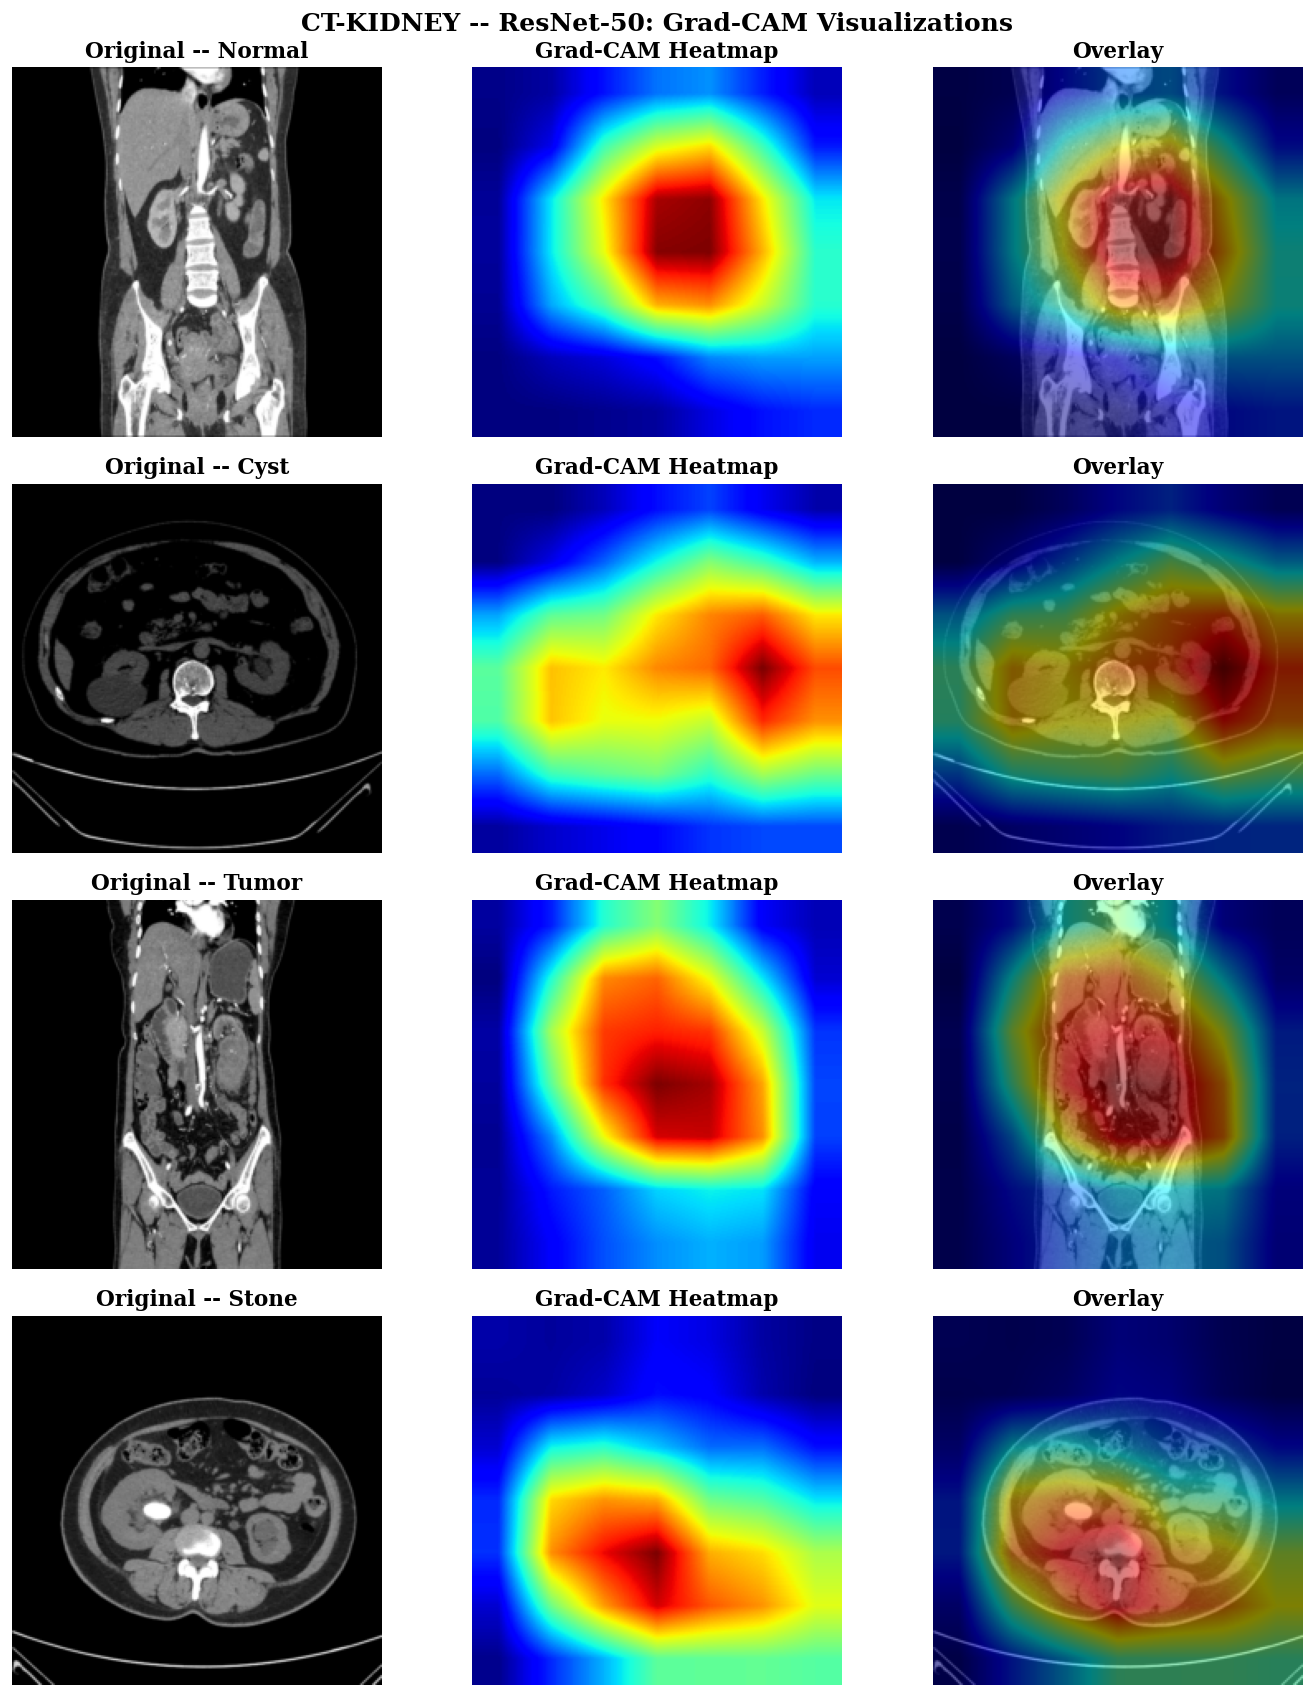

Saved: figures\CT-KIDNEY\ResNet-50_gradcam.png

Generating Grad-CAM for VGG-16 on CT-KIDNEY ...


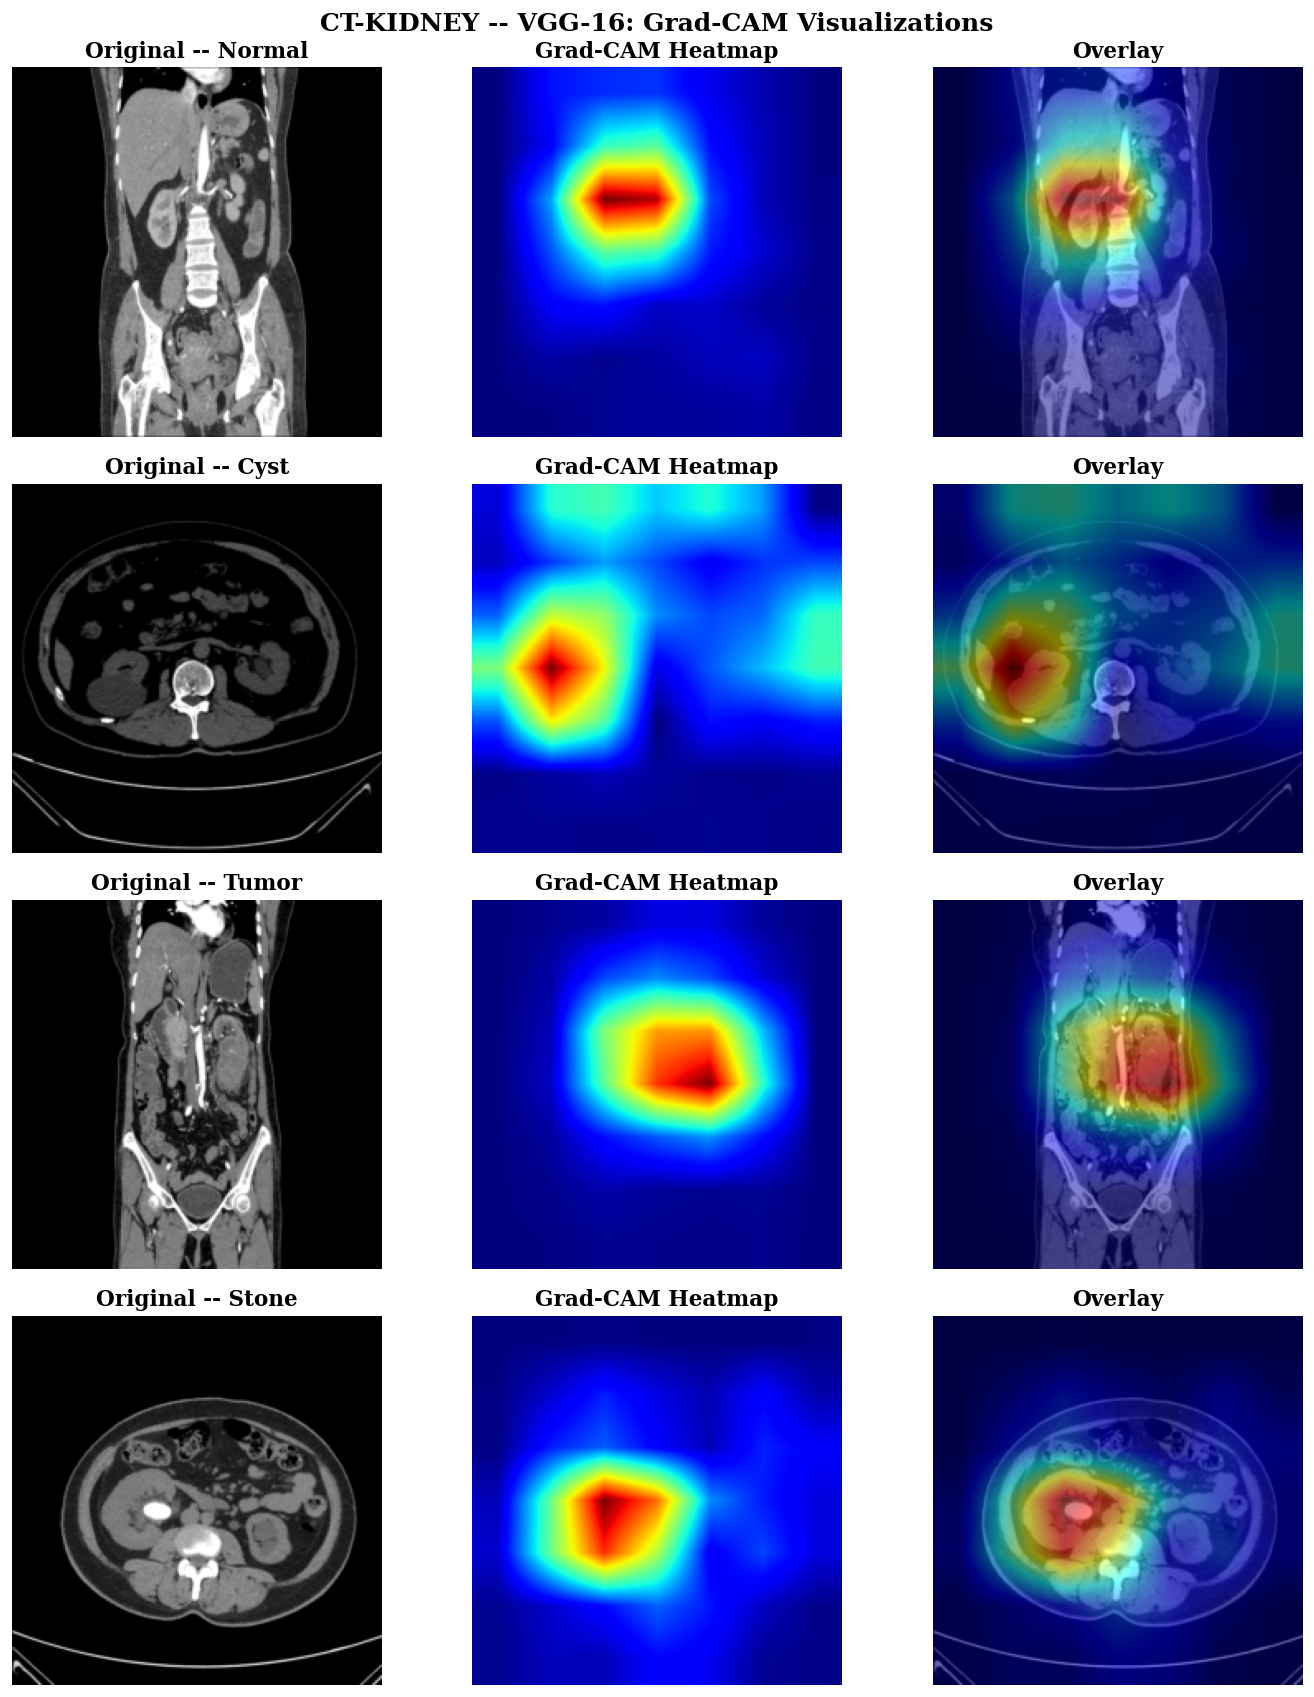

Saved: figures\CT-KIDNEY\VGG-16_gradcam.png

Generating Grad-CAM for MUL-CNN on CT-KIDNEY ...


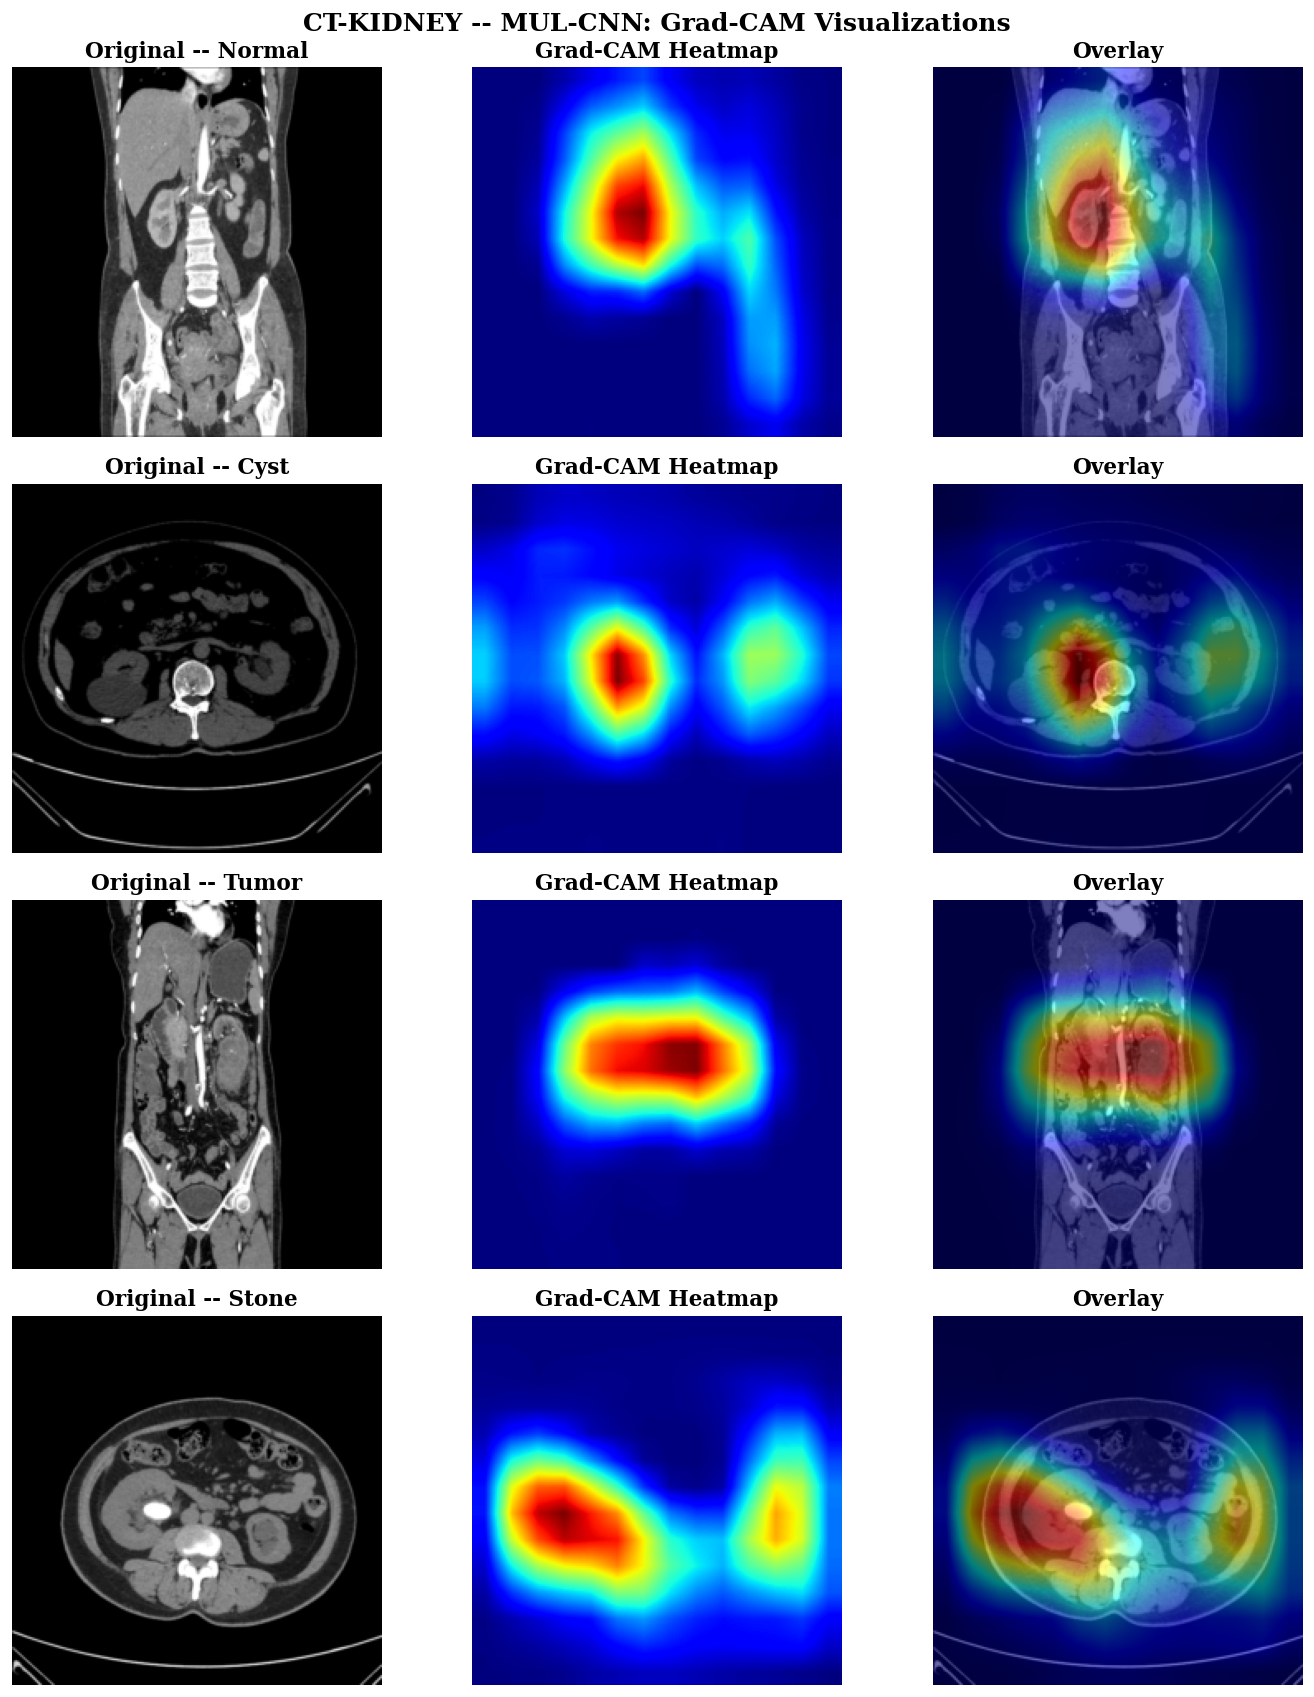

Saved: figures\CT-KIDNEY\MUL-CNN_gradcam.png

GRAD-CAM: RenSeg-KidneyCT

Generating Grad-CAM for ResNet-50 on RenSeg-KidneyCT ...


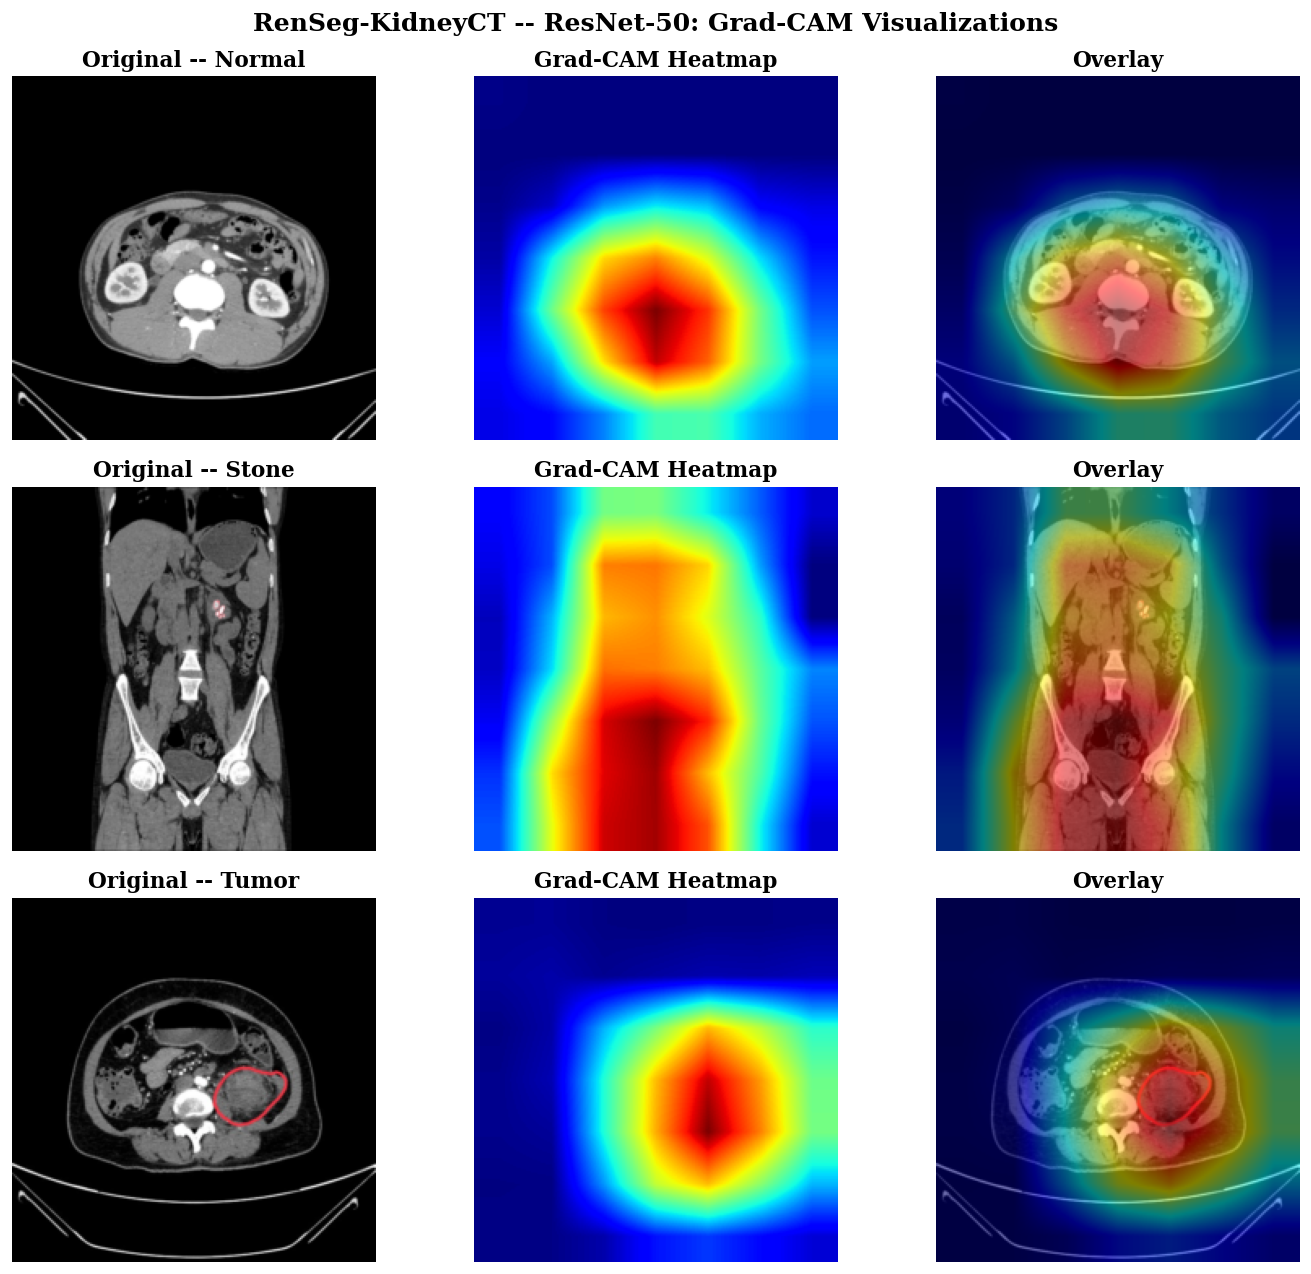

Saved: figures\RenSeg-KidneyCT\ResNet-50_gradcam.png

Generating Grad-CAM for VGG-16 on RenSeg-KidneyCT ...


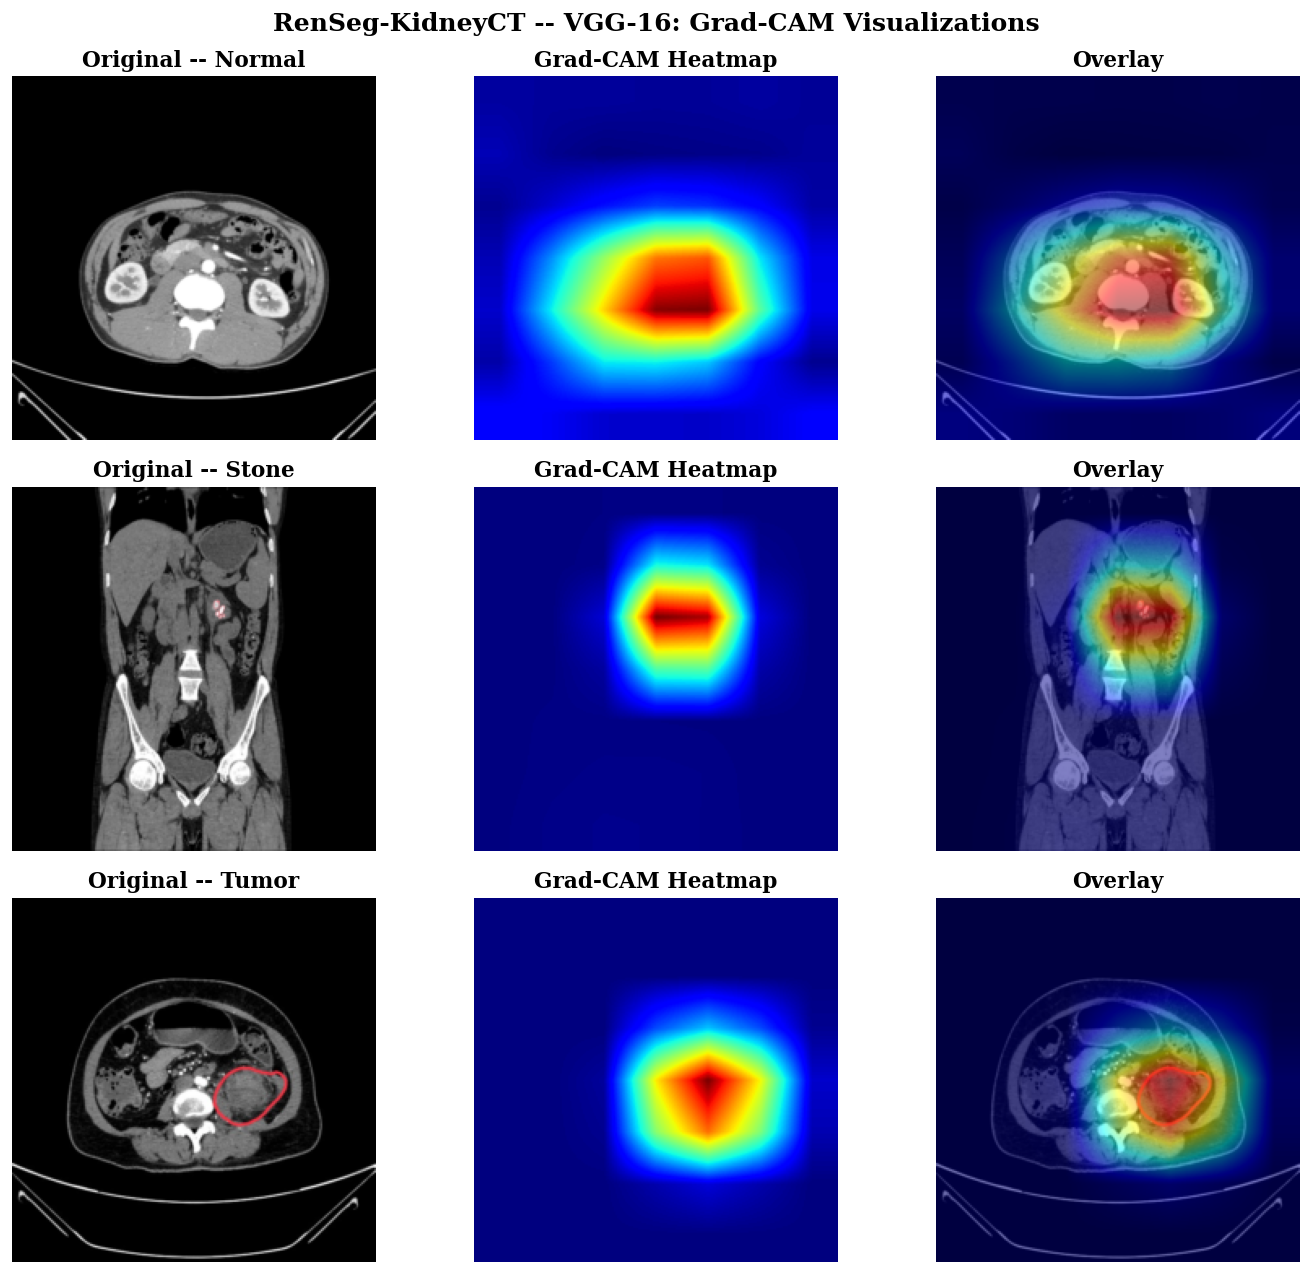

Saved: figures\RenSeg-KidneyCT\VGG-16_gradcam.png

Generating Grad-CAM for MUL-CNN on RenSeg-KidneyCT ...


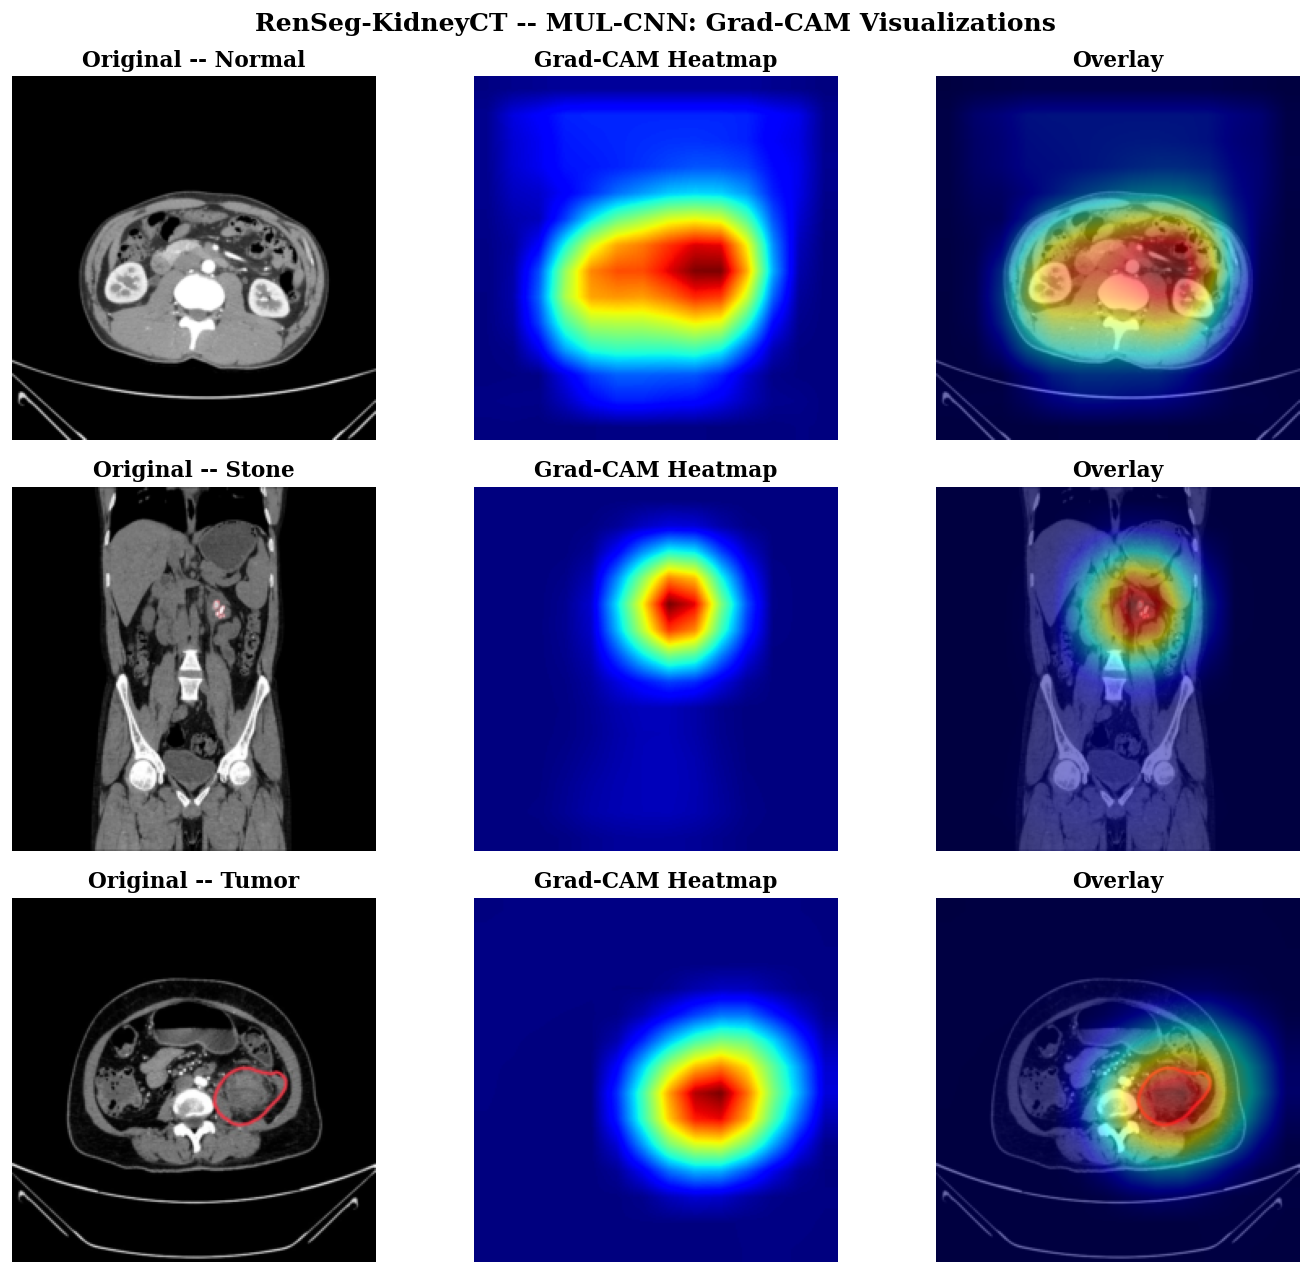

Saved: figures\RenSeg-KidneyCT\MUL-CNN_gradcam.png


In [26]:
# ----------------------------------------------------------------------------
# 15.2 Run Grad-CAM for every primary model, on every dataset
# ----------------------------------------------------------------------------
if GLOBAL_CFG['run_gradcam']:
    for _dkey in DATASETS_CFG:
        print(f"\n{'='*78}\nGRAD-CAM: {_dkey}\n{'='*78}")
        for _mname in GLOBAL_CFG['primary_models']:
            print(f"\nGenerating Grad-CAM for {_mname} on {_dkey} ...")
            visualize_gradcam(
                ALL_MODELS[_dkey][_mname], _mname, _dkey,
                DATASETS_TORCH[_dkey]['test'],
                num_samples_per_class=GLOBAL_CFG['gradcam_num_samples_per_class'])


---
## 17. Publication-Ready Comparative Figures

Per-model, per-dataset figures (training curves, confusion matrices,
Grad-CAM, perturbation robustness) were already saved into `figures/` as
they were generated in earlier sections. This section adds the
**cross-model, cross-dataset comparative figures** a paper actually needs
for its results section -- accuracy/F1/parameter-count/inference-time
comparisons -- generated in the same style (300 DPI, yellow/amber palette,
serif typography) and saved under `figures/comparative/`.


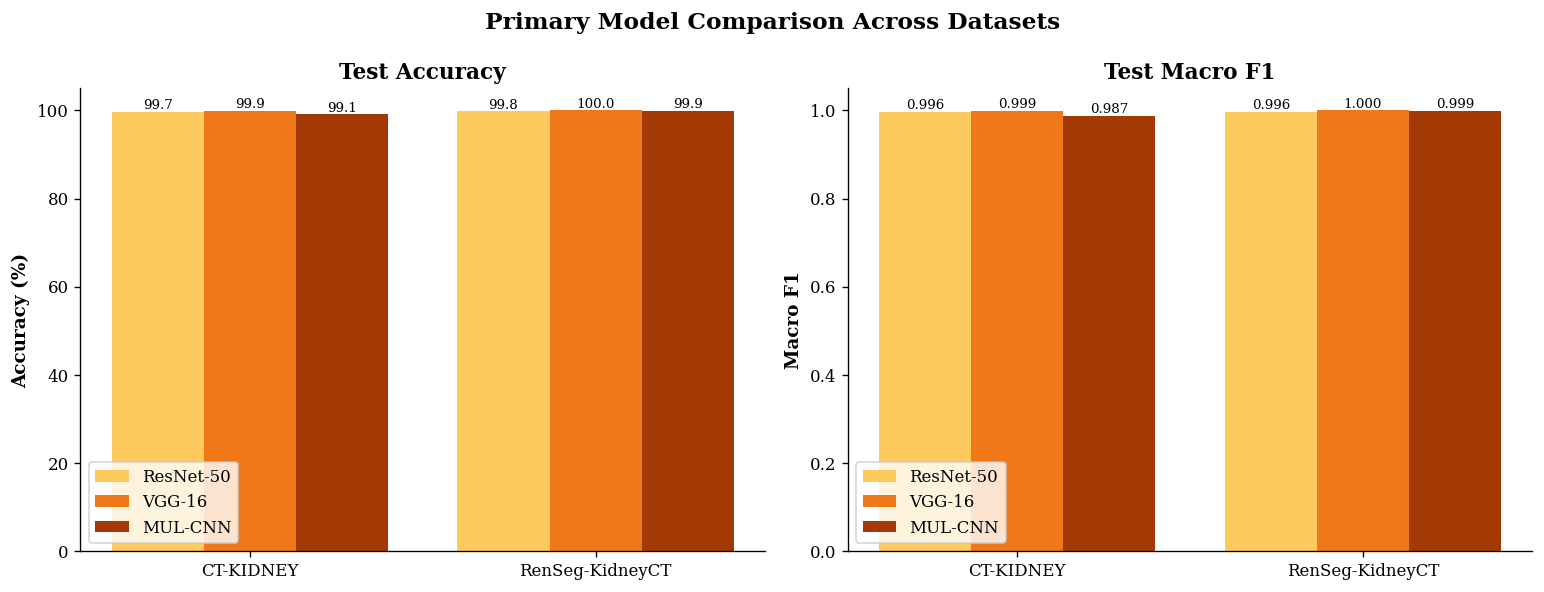

In [27]:
# ----------------------------------------------------------------------------
# 17.1 Grouped bar chart: accuracy and macro F1 across models x datasets
# ----------------------------------------------------------------------------
_dataset_keys = list(DATASETS_CFG.keys())
_model_keys = GLOBAL_CFG['primary_models']
_bar_colors = plt.cm.YlOrBr(np.linspace(0.35, 0.85, len(_model_keys)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title, ylabel in [
    (axes[0], 'accuracy', 'Test Accuracy', 'Accuracy (%)'),
    (axes[1], 'f1_score', 'Test Macro F1', 'Macro F1'),
]:
    _x = np.arange(len(_dataset_keys))
    _width = 0.8 / len(_model_keys)
    for i, _mname in enumerate(_model_keys):
        _vals = [ALL_RESULTS[_dkey][_mname][metric] * (100 if metric == 'accuracy' else 1)
                 for _dkey in _dataset_keys]
        ax.bar(_x + i * _width, _vals, width=_width, label=_mname, color=_bar_colors[i])
        for xi, v in zip(_x + i * _width, _vals):
            ax.text(xi, v, f'{v:.1f}' if metric == 'accuracy' else f'{v:.3f}',
                    ha='center', va='bottom', fontsize=8)
    ax.set_xticks(_x + _width * (len(_model_keys) - 1) / 2)
    ax.set_xticklabels(_dataset_keys)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend()

fig.suptitle('Primary Model Comparison Across Datasets')
fig.tight_layout()
save_fig(fig, 'comparative', 'accuracy_f1_comparison')
plt.show()


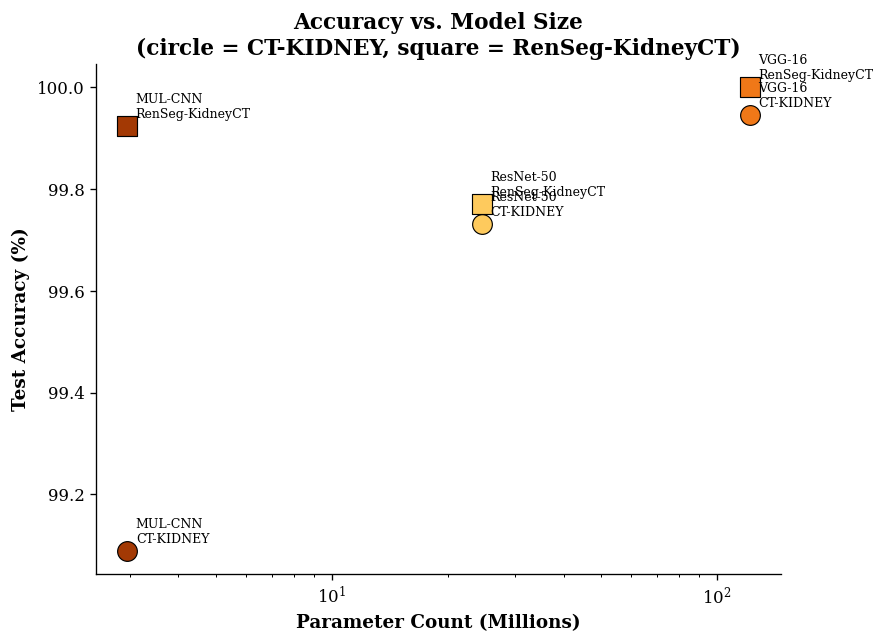

In [28]:
# ----------------------------------------------------------------------------
# 17.2 Parameter count vs. accuracy scatter (efficiency framing)
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 5.5))
_markers = {'CT-KIDNEY': 'o', 'RenSeg-KidneyCT': 's'}
for _dkey in _dataset_keys:
    for i, _mname in enumerate(_model_keys):
        res = ALL_RESULTS[_dkey][_mname]
        ax.scatter(res['params_millions'], res['accuracy'] * 100, s=140,
                   color=_bar_colors[i], marker=_markers[_dkey], edgecolor='black', linewidth=0.7,
                   label=f'{_mname} ({_dkey})')
        ax.annotate(f'{_mname}\n{_dkey}', (res['params_millions'], res['accuracy'] * 100),
                    fontsize=7.5, xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Parameter Count (Millions)')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Accuracy vs. Model Size\n(circle = CT-KIDNEY, square = RenSeg-KidneyCT)')
ax.set_xscale('log')
fig.tight_layout()
save_fig(fig, 'comparative', 'accuracy_vs_params')
plt.show()


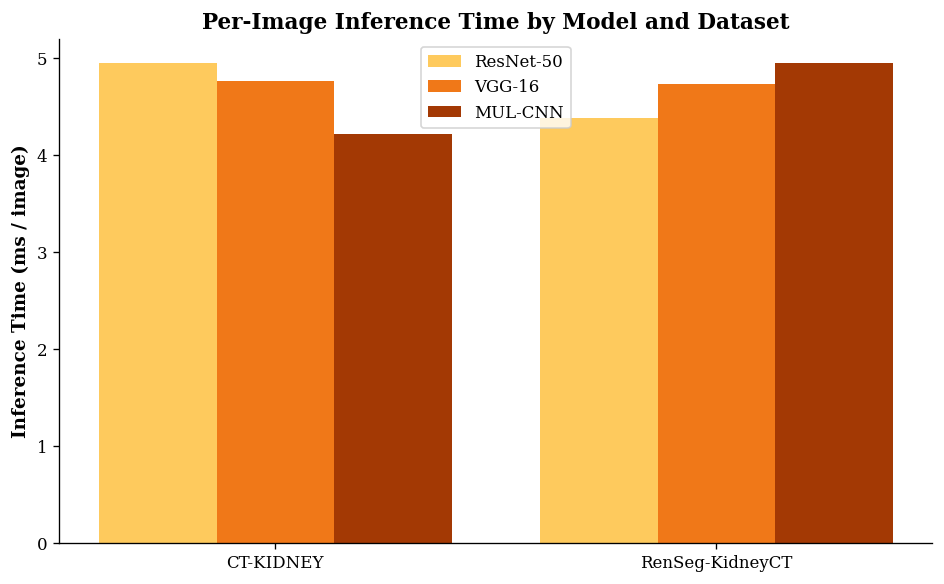

In [29]:
# ----------------------------------------------------------------------------
# 17.3 Inference-time comparison
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
_x = np.arange(len(_dataset_keys))
_width = 0.8 / len(_model_keys)
for i, _mname in enumerate(_model_keys):
    _vals = [ALL_RESULTS[_dkey][_mname]['inference_time_ms'] for _dkey in _dataset_keys]
    ax.bar(_x + i * _width, _vals, width=_width, label=_mname, color=_bar_colors[i])
ax.set_xticks(_x + _width * (len(_model_keys) - 1) / 2)
ax.set_xticklabels(_dataset_keys)
ax.set_ylabel('Inference Time (ms / image)')
ax.set_title('Per-Image Inference Time by Model and Dataset')
ax.legend()
fig.tight_layout()
save_fig(fig, 'comparative', 'inference_time_comparison')
plt.show()


---
## 18. Final Consolidated Results Summary

Every table and figure produced by this notebook is pulled together here
into a small set of consolidated exports (CSV for spreadsheets/further
analysis, Markdown for pasting straight into the paper) written to
`results/`. This is intended to be the single place to look when rewriting
the paper's Results section.


In [30]:
# ----------------------------------------------------------------------------
# 18.1 Primary results table (all models x all datasets)
# ----------------------------------------------------------------------------
_rows = []
for _dkey in DATASETS_CFG:
    for _mname in GLOBAL_CFG['primary_models']:
        res = ALL_RESULTS[_dkey][_mname]
        _rows.append({
            'Dataset': _dkey, 'Model': _mname,
            'Accuracy (%)': round(res['accuracy'] * 100, 2),
            'Precision (macro)': round(res['precision'], 4),
            'Recall (macro)': round(res['recall'], 4),
            'Macro F1': round(res['f1_score'], 4),
            'Params (M)': round(res['params_millions'], 3),
            'Inference (ms/img)': round(res['inference_time_ms'], 3),
        })
PRIMARY_RESULTS_TABLE = pd.DataFrame(_rows)
print("PRIMARY RESULTS SUMMARY (all models x all datasets):")
display(PRIMARY_RESULTS_TABLE)
PRIMARY_RESULTS_TABLE.to_csv(Path(GLOBAL_CFG['results_dir']) / 'primary_results_summary.csv', index=False)
with open(Path(GLOBAL_CFG['results_dir']) / 'primary_results_summary.md', 'w') as f:
    f.write(PRIMARY_RESULTS_TABLE.to_markdown(index=False))


PRIMARY RESULTS SUMMARY (all models x all datasets):


,Dataset,Model,Accuracy (%),Precision (macro),Recall (macro),Macro F1,Params (M),Inference (ms/img)
0,CT-KIDNEY,ResNet-50,99.73,0.9965,0.9955,0.9960,24.559,4.956
1,CT-KIDNEY,VGG-16,99.95,0.9988,0.9996,0.9992,121.679,4.770
2,CT-KIDNEY,MUL-CNN,99.09,0.9884,0.9865,0.9874,2.948,4.225
3,RenSeg-KidneyCT,ResNet-50,99.77,0.9958,0.9964,0.9961,24.559,4.382
4,RenSeg-KidneyCT,VGG-16,100.00,1.0000,1.0000,1.0000,121.678,4.736
5,RenSeg-KidneyCT,MUL-CNN,99.92,0.9996,0.9984,0.9990,2.948,4.949


In [31]:
# ----------------------------------------------------------------------------
# 18.2 Export every other table generated in this notebook
# ----------------------------------------------------------------------------
_exported = ['primary_results_summary.csv', 'primary_results_summary.md']

for _dkey in DATASETS_CFG:
    DATASET_STATS[_dkey].to_csv(Path(GLOBAL_CFG['results_dir']) / f'{_dkey}__dataset_statistics.csv', index=False)
    SPLIT_STATS[_dkey].to_csv(Path(GLOBAL_CFG['results_dir']) / f'{_dkey}__split_statistics.csv', index=False)
    MCNEMAR_RESULTS[_dkey].to_csv(Path(GLOBAL_CFG['results_dir']) / f'{_dkey}__mcnemar_tests.csv', index=False)
    BOOTSTRAP_CI_RESULTS[_dkey].to_csv(Path(GLOBAL_CFG['results_dir']) / f'{_dkey}__bootstrap_ci.csv', index=False)
    _exported += [f'{_dkey}__dataset_statistics.csv', f'{_dkey}__split_statistics.csv',
                  f'{_dkey}__mcnemar_tests.csv', f'{_dkey}__bootstrap_ci.csv']

    for _mname in GLOBAL_CFG['primary_models']:
        ALL_PERCLASS_TABLES[_dkey][_mname].to_csv(
            Path(GLOBAL_CFG['results_dir']) / f'{_dkey}__{_mname}__per_class_metrics.csv', index=False)
        _exported.append(f'{_dkey}__{_mname}__per_class_metrics.csv')

    if GLOBAL_CFG['run_perturbation_robustness']:
        PERTURBATION_RESULTS[_dkey].to_csv(
            Path(GLOBAL_CFG['results_dir']) / f'{_dkey}__perturbation_robustness.csv', index=False)
        _exported.append(f'{_dkey}__perturbation_robustness.csv')

if GLOBAL_CFG['run_seed_robustness'] and isinstance(SEED_ROBUSTNESS_SUMMARY, pd.DataFrame):
    SEED_ROBUSTNESS_SUMMARY.to_csv(Path(GLOBAL_CFG['results_dir']) / 'seed_robustness_summary.csv', index=False)
    _exported.append('seed_robustness_summary.csv')



print(f"Exported {len(_exported)} result files to '{GLOBAL_CFG['results_dir']}/':")
for _f in _exported:
    print(f"  - {_f}")


Exported 19 result files to 'results/':
  - primary_results_summary.csv
  - primary_results_summary.md
  - CT-KIDNEY__dataset_statistics.csv
  - CT-KIDNEY__split_statistics.csv
  - CT-KIDNEY__mcnemar_tests.csv
  - CT-KIDNEY__bootstrap_ci.csv
  - CT-KIDNEY__ResNet-50__per_class_metrics.csv
  - CT-KIDNEY__VGG-16__per_class_metrics.csv
  - CT-KIDNEY__MUL-CNN__per_class_metrics.csv
  - CT-KIDNEY__perturbation_robustness.csv
  - RenSeg-KidneyCT__dataset_statistics.csv
  - RenSeg-KidneyCT__split_statistics.csv
  - RenSeg-KidneyCT__mcnemar_tests.csv
  - RenSeg-KidneyCT__bootstrap_ci.csv
  - RenSeg-KidneyCT__ResNet-50__per_class_metrics.csv
  - RenSeg-KidneyCT__VGG-16__per_class_metrics.csv
  - RenSeg-KidneyCT__MUL-CNN__per_class_metrics.csv
  - RenSeg-KidneyCT__perturbation_robustness.csv
  - seed_robustness_summary.csv


### 18.3 Where everything lives

- **`checkpoints/`** -- best-validation-metric model weights for every
  training run in this notebook (primary models, seed-robustness runs,
  ablation variants), named `<dataset>__<tag>.pt`.
- **`figures/<dataset>/`** -- every per-model, per-dataset figure (training
  curves, confusion matrices, Grad-CAM panels, perturbation-robustness
  chart), PNG (300 DPI) + PDF.
- **`figures/comparative/`** -- cross-model, cross-dataset comparison
  figures (Section 17).
- **`results/`** -- every table in this notebook, exported as CSV and (for
  the primary results table) Markdown, ready to paste into the paper.

Re-running Section 12 (primary experiments) is the only expensive step;
everything from Section 13 onward is cheap and reuses its output.


In [32]:
print("=" * 90)
print("NOTEBOOK COMPLETE")
print("=" * 90)
print(f"Datasets processed        : {list(DATASETS_CFG.keys())}")
print(f"Primary models compared   : {GLOBAL_CFG['primary_models']}")
print(f"Augmentation ablation run : {GLOBAL_CFG['run_augmentation_ablation']}")
print(f"Multi-seed robustness run : {GLOBAL_CFG['run_seed_robustness']}")
print(f"Perturbation robustness run: {GLOBAL_CFG['run_perturbation_robustness']}")
print(f"Grad-CAM run              : {GLOBAL_CFG['run_gradcam']}")
print(f"Checkpoints directory     : {GLOBAL_CFG['checkpoints_dir']}/")
print(f"Figures directory         : {GLOBAL_CFG['figures_dir']}/")
print(f"Results directory         : {GLOBAL_CFG['results_dir']}/")


NOTEBOOK COMPLETE
Datasets processed        : ['CT-KIDNEY', 'RenSeg-KidneyCT']
Primary models compared   : ['ResNet-50', 'VGG-16', 'MUL-CNN']
Augmentation ablation run : True
Multi-seed robustness run : True
Perturbation robustness run: True
Grad-CAM run              : True
Checkpoints directory     : checkpoints/
Figures directory         : figures/
Results directory         : results/
